# U.S. crude oil supply, demand, and stocks

## Preface
This project is meant to help me gain a better understanding of how the EIA data is structured, learn about the different PADDs, and have fun testing various models on the data. It is not meant to be accurate as there is a lot of information that I am missing to create an accurate supply & demand model. I don't have refinery turnarounds, all the data sources, etc.

This model forecasts commercial crude stocks (Strategic Petroleum Reserve (SPR) is omitted). Refinery runs are the main source of domestic crude demand.

We model the five PADDs separately and add their forecasts to obtain U.S. stock levels.

Historical tests compare each method with carrying the latest stock level forward. The final two years are kept out of model selection. A separate test checks how errors develop over a twelve-month forecast.

### COVID exclusion

March 2020 through March 2021, inclusive, is excluded from model fitting due to how COVID affected the market.

Stock fitting excludes any row when its prior-month, two-month-prior, or prior-year input falls within that period. As a result, stock-model training targets from March 2020 through March 2022 are left out. Flow fits, seasonal averages, and stock change use only observations outside the 13-month exclusion period.

In [1]:
# Run cells from top to bottom: later cells reuse the data, functions, and fitted
# models created here. pandas/NumPy handle monthly tables and arrays, sklearn
# and XGBoost fit models, matplotlib draws charts, and joblib saves estimators.
from pathlib import Path
import json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, sklearn, xgboost
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from IPython.display import display, Markdown

# Only input data are external. No local Python module is imported.
# Support execution from either the product folder or the commodities workspace.
# Fail early if the saved EIA observation CSV cannot be found.
HERE=Path.cwd()
if not (HERE/'data/eia_observations.csv').exists():
    HERE=HERE/'oil'/'us_snd_crude'
assert (HERE/'data/eia_observations.csv').exists(), 'Keep the data folder beside this notebook.'
OUTPUT=HERE/'model_output'
# These settings affect chart/table presentation only, not stored model values.
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')

# Dates represent observation months using their first day. Both exclusion
# endpoints are inclusive; keep the raw calendar intact so lags retain their meaning.
COVID_START = pd.Timestamp('2020-03-01')
COVID_END = pd.Timestamp('2021-03-01')


# Return one Boolean per date: True means outside the excluded COVID interval.
def outside_covid(months):
    dates = pd.DatetimeIndex(months)
    return ~((dates >= COVID_START) & (dates <= COVID_END))


# Filter fitting rows after constructing lagged features on the intact calendar.
# A clean target is insufficient if one of its direct lag inputs is excluded.
def training_rows(frame):
    """Exclude COVID targets and any training row whose direct inputs touch COVID."""
    dates = pd.DatetimeIndex(frame.month)
    keep = outside_covid(dates)
    # lag1 stocks/flows, lag2 for the latest change, lag12 for annual stocks.
    for lag in [1, 2, 12]:
        keep &= outside_covid(dates - pd.DateOffset(months=lag))
    return frame.loc[keep]


# Create chronological expanding-window folds; never shuffle time-series rows.
# This filter concerns target dates; fitting applies the stricter lag-input filter.
def validation_splits(frame, folds=10, test_size=None):
    """Split eligible target dates, retaining real calendar positions and lag dates."""
    allowed = np.flatnonzero(outside_covid(frame.month))
    splitter = TimeSeriesSplit(n_splits=folds, test_size=test_size)
    # Map positions within eligible dates back to the original frame. A test block
    # of 12 eligible observations may span more than 12 calendar months.
    return [(allowed[tr], allowed[te]) for tr, te in splitter.split(allowed)]


# Search backward in annual steps for six eligible year-long development paths.
# Each origin leaves its next 12 forecast months inside development history.
def recursive_origins(development_end, count=6):
    """Use six full test years that do not overlap the excluded interval."""
    origins = []
    cutoff = development_end - pd.DateOffset(years=1)
    while len(origins) < count:
        months = pd.date_range(cutoff + pd.offsets.MonthBegin(), periods=12, freq='MS')
        if outside_covid(months).all() and outside_covid([cutoff]).all():
            origins.append(cutoff)
        cutoff -= pd.DateOffset(years=1)
    return sorted(origins)

## 1. Model scope and design

The model compares monthly flows with the change in stocks from the previous month to the current month. It uses commercial stock data and reported regional flow data, while any unexplained difference is residual. Forecast inputs include only information that was available before the month being predicted.

The following models are used: seasonal baselines, constrained regression, regularized regression, nonlinear models, recent-history fitting, shrinkage, and an ensemble.

Regional forecasts are added together first, and the total is compared with the actual national result.

The model choice for one-month forecasts is made separately from the choices for twelve-month forecasts. Each month in the twelve-month forecast can also use its own model settings.

## 2. Sources, units, and stock scope

The data snapshot contains 50 active EIA series, ten per PADD from January 2007 onward (random starting point).

| Measure | PADD 1 | PADD 2 | PADD 3 | PADD 4 | PADD 5 |
|---|---|---|---|---|---|
| Field production | `MCRFPP11` | `MCRFPP21` | `MCRFPP31` | `MCRFPP41` | `MCRFPP51` |
| Refinery and blender net input | `MCRRIP11` | `MCRRIP21` | `MCRRIP31` | `MCRRIP41` | `MCRRIP51` |
| Imports | `MCRIMP11` | `MCRIMP21` | `MCRIMP31` | `MCRIMP41` | `MCRIMP51` |
| Exports | `MCREXP11` | `MCREXP21` | `MCREXP31` | `MCREXP41` | `MCREXP51` |
| Net receipts from other PADDs | `MCRNRP11` | `MCRNRP21` | `MCRNRP31` | `MCRNRP41` | `MCRNRP51` |
| Supply adjustment | `MCRUA_R10_1` | `MCRUA_R20_1` | `MCRUA_R30_1` | `MCRUA_R40_1` | `MCRUA_R50_1` |
| Transfers to crude-oil supply | `M_EPC0_TVP_R10_MBBL` | `M_EPC0_TVP_R20_MBBL` | `M_EPC0_TVP_R30_MBBL` | `M_EPC0_TVP_R40_MBBL` | `M_EPC0_TVP_R50_MBBL` |
| Product supplied | `MCRUPP11` | `MCRUPP21` | `MCRUPP31` | `MCRUPP41` | `MCRUPP51` |
| Ending stocks, excluding SPR | `MCESTP11` | `MCESTP21` | `MCESTP31` | `MCESTP41` | `MCESTP51` |

Stocks show how much crude oil is available at the end of each month. They are measured in thousand barrels and labeled `_kb`.

Flows show daily crude-oil activity, such as production, imports, refinery use, and exports. They are measured in thousand barrels per day and labeled `_kbd`.

EIA reports some flows as total amounts for the month. The model converts them to daily amounts by dividing each monthly total by the actual number of days in that month.

The crude-oil balance includes:

- Production
- Imports
- Oil received from other PADD regions
- Supply adjustments
- Transfers into the crude supply
- Refinery inputs
- Exports
- Direct crude use

The model uses the amount of crude refining capacity that is available to operate. Refinery utilization is calculated by dividing crude sent to refineries each day by the available crude-refining capacity.

This utilization measure is narrower than EIA’s gross input utilization measure because it includes crude oil only, not other refinery feedstocks.

### Series map and input preparation

This shows exactly which EIA series the model uses and whether each one adds to or subtracts from the balance.

`load_panel` organizes the data into a complete monthly table for each PADD. It keeps track of values that were assumed to be zero, uses commercial stock data, calculates refinery utilization, and measures the historical difference between the reported flows and the change in stocks.

In [2]:
# PADDs are the five Petroleum Administration for Defense Districts. Series
# templates substitute {p} with the district number when identifying source data.
PADD_NAMES = {1: 'East Coast', 2: 'Midwest', 3: 'Gulf Coast', 4: 'Rocky Mountain', 5: 'West Coast'}
CODES = {'production_kbd': 'MCRFPP{p}1', 'demand_kbd': 'MCRRIP{p}1',
         'imports_kbd': 'MCRIMP{p}1', 'exports_kbd': 'MCREXP{p}1',
         'net_receipts_kbd': 'MCRNRP{p}1', 'adjustments_kbd': 'MCRUA_R{p}0_1',
         'transfers_kbd': 'M_EPC0_TVP_R{p}0_MBBL', 'direct_use_kbd': 'MCRUPP{p}1',
         'stock_kb': 'MCESTP{p}1', 'cdu_capacity_kbd': 'MOCLEP{p}2'}
# Keep this order aligned with SIGNS: the dot product uses +1 for supply
# additions and -1 for disposition to reconstruct net supply.
FLOWS = ['production_kbd', 'demand_kbd', 'imports_kbd', 'exports_kbd',
         'net_receipts_kbd', 'adjustments_kbd', 'transfers_kbd', 'direct_use_kbd']
SIGNS = [1, -1, 1, -1, 1, 1, 1, -1]
# The downloaded transfer series start in January 2022; earlier rows are structural zeros.
SPARSE = {'exports_kbd', 'transfers_kbd', 'net_receipts_kbd'}

In [3]:
# Return one row per PADD/month with flows, month-end stocks, assumption flags,
# and balance diagnostics, starting from the saved long-form EIA observations.
def load_panel(data_dir=HERE / 'data', start='2007-01-01'):
    # Parse timestamps for exact calendar reindexing and month-length calculations.
    raw = pd.read_csv(Path(data_dir) / 'eia_observations.csv', parse_dates=['month'])
    # Raw flow snapshots retain EIA monthly volumes; convert exactly once here.
    raw['component'] = raw.component.replace({c.replace('_kbd', '_kb'): c for c in FLOWS})
    raw = raw[raw.component.isin(FLOWS + ['commercial_stock_kb', 'cdu_capacity_kbd'])].copy()
    raw['component'] = raw.component.replace({'commercial_stock_kb': 'stock_kb'})
    raw['value'] = raw.value.astype(float)
    is_flow = raw.component.isin(FLOWS)
    raw.loc[is_flow, 'value'] /= raw.loc[is_flow, 'month'].dt.days_in_month
    # The pivot requires a single observation per month/PADD/component combination.
    if raw.duplicated(['month', 'padd', 'component']).any():
        raise ValueError('Duplicate EIA observations')
    panels = []
    for p in PADD_NAMES:
        r = raw[raw.padd.eq(p)]
        # Use the latest observed stock month as this district's provisional endpoint.
        end = r[r.component.eq('stock_kb') & r.value.notna()].month.max()
        index = pd.date_range(start, end, freq='MS')
        # Turn component names into columns, then expose absent months on a continuous
        # month-start calendar. Reindexing does not interpolate missing observations.
        wide = r.pivot(index='month', columns='component', values='value').reindex(index)
        for c in SPARSE:
            rows = r[r.component.eq(c)].set_index('month')
            # Missing calendar rows in sparse export/transfer sheets are an explicit
            # no-reported-flow assumption, not interpolation from future values.
            absent = ~wide.index.isin(rows.index)
            # Combine source zero flags with wholly absent sparse-series rows. An explicit
            # unavailable value on an existing row remains missing instead of becoming zero.
            wide[c + '_assumed_zero'] = rows.assumed_zero.reindex(index).astype("boolean").fillna(False).astype(bool) | absent
            wide.loc[absent, c] = 0.0
        wide['padd'] = p
        wide['padd_name'] = PADD_NAMES[p]
        wide.index.name = 'month'
        panels.append(wide.reset_index())
    panel = pd.concat(panels, ignore_index=True)
    core = FLOWS + ['stock_kb', 'cdu_capacity_kbd']
    # Find the last month complete in all five districts, then trim to a shared
    # endpoint so national totals compare the same observation months.
    valid = panel[core].notna().all(axis=1)
    common = panel[valid].groupby('month').padd.nunique()
    end = common[common.eq(5)].index.max()
    panel = panel[panel.month.le(end)].copy()
    # Earlier unresolved gaps still fail validation: trimming the endpoint does not
    # authorize filling withheld values or dropping an incomplete district.
    if panel[core].isna().any().any():
        raise ValueError('Unresolved missing core data; inspect the source snapshots')
    if not panel.groupby('padd').size().eq(len(pd.date_range(start, end, freq='MS'))).all():
        raise ValueError('Incomplete PADD calendar')
    if panel.cdu_capacity_kbd.le(0).any():
        raise ValueError('CDU capacity must be positive')
    panel['utilization_ratio'] = panel.demand_kbd / panel.cdu_capacity_kbd
    # Shift within each district so prior stock never comes from another PADD.
    # The first month has no predecessor and therefore a missing stock change.
    panel['previous_stock_kb'] = panel.groupby('padd').stock_kb.shift(1)
    # Sum signed daily flows. Compare this with stock change divided by month length
    # so both sides of the crude reconciliation are in thousand barrels per day.
    panel['balance_kbd'] = panel[FLOWS].to_numpy() @ SIGNS
    panel['stock_change_kb'] = panel.stock_kb - panel.previous_stock_kb
    # Despite its legacy name, this diagnostic uses four flows: production plus
    # imports minus refinery demand and exports. The remaining terms are omitted.
    panel['five_term_balance_kbd'] = panel.production_kbd + panel.imports_kbd - panel.demand_kbd - panel.exports_kbd
    panel['five_term_residual_kbd'] = panel.stock_change_kb / panel.month.dt.days_in_month - panel.five_term_balance_kbd
    panel['accounting_residual_kbd'] = panel.stock_change_kb / panel.month.dt.days_in_month - panel.balance_kbd
    return panel

In [4]:
# Audit the loaded snapshot: show Gulf Coast source identifiers, each PADD's
# calendar coverage, counts of assumed-zero observations, and latest refinery
# input/capacity. Flags make missing-data assumptions visible before fitting.

panel=load_panel(HERE/'data')
manifest=pd.read_json(HERE/'data/source_manifest.json')
display(manifest[manifest.padd.eq(3)][['component','series_id','title']])
display(panel.groupby('padd').agg(start=('month','min'),end=('month','max'),months=('month','size')))
flags=[c for c in panel if c.endswith('_assumed_zero')]
display(panel.groupby('padd')[flags].sum())
display(panel.sort_values('month').groupby('padd').tail(1)[
    ['padd','padd_name','month','cdu_capacity_kbd','demand_kbd','utilization_ratio']].sort_values('padd'))

,component,series_id,title
18,production_kb,MCRFPP31,Gulf Coast (PADD 3) Field Production of Crude ...
19,demand_kb,MCRRIP31,Gulf Coast (PADD 3) Refinery and Blender Net I...
20,imports_kb,MCRIMP31,Gulf Coast (PADD 3) Imports of Crude Oil (Thou...
21,exports_kb,MCREXP31,Gulf Coast (PADD 3) Exports of Crude Oil (Thou...
22,net_receipts_kb,MCRNRP31,"Gulf Coast (PADD 3) Net Receipts by Pipeline, ..."
23,adjustments_kb,MCRUA_R30_1,Gulf Coast (PADD 3) Supply Adjustment of Crude...
24,transfers_kb,M_EPC0_TVP_R30_MBBL,Gulf Coast (PADD 3) Transfers to Crude Oil Sup...
25,direct_use_kb,MCRUPP31,Gulf Coast (PADD 3) Product Supplied of Crude ...
26,commercial_stock_kb,MCESTP31,Gulf Coast (PADD 3) Ending Stocks excluding SP...
47,cdu_capacity_kbd,MOCLEP32,Gulf Coast (PADD 3) Operable Crude Oil Distill...


,start,end,months
padd,,,
1,2007-01-01,2026-06-01,234
2,2007-01-01,2026-06-01,234
3,2007-01-01,2026-06-01,234
4,2007-01-01,2026-06-01,234
5,2007-01-01,2026-06-01,234


component,exports_kbd_assumed_zero,transfers_kbd_assumed_zero,net_receipts_kbd_assumed_zero
padd,,,
1,21,180,0
2,0,180,0
3,63,180,0
4,98,180,0
5,103,180,43


component,padd,padd_name,month,cdu_capacity_kbd,demand_kbd,utilization_ratio
233,1,East Coast,2026-06-01,928.00,727.00,0.78
467,2,Midwest,2026-06-01,"4,283.00","4,291.17",1.00
701,3,Gulf Coast,2026-06-01,"9,888.00","9,525.30",0.96
935,4,Rocky Mountain,2026-06-01,653.00,656.33,1.01
1169,5,West Coast,2026-06-01,"2,275.00","2,000.47",0.88


When EIA leaves an exports or net-receipts cell blank, the model treats it as zero and marks it as an assumed value.

The transfer data starts in January 2022. For earlier months, the model enters zero because that reporting category did not yet exist. This does not mean no transfers physically occurred; it only reflects how the published data is organized.

Values marked as unavailable or withheld are kept as missing rather than changed to zero. If important data is still missing, the model stops and reports an error.

The model also requires all five PADD regions to have a complete monthly calendar ending on the same date.

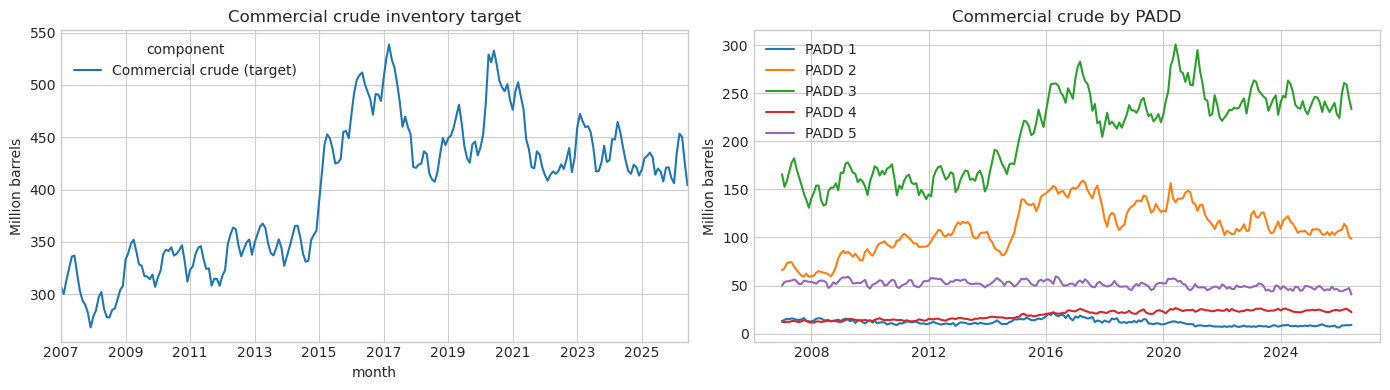

In [5]:
# Plot commercial inventories, excluding SPR, at national and regional scales.
# Stocks are stored in thousand barrels; dividing by 1000 gives million barrels.

national_history=panel.groupby('month')[['stock_kb']].sum()
fig,axes=plt.subplots(1,2,figsize=(14,4))
(national_history/1000).rename(columns={'stock_kb':'Commercial crude (target)'}).plot(ax=axes[0])
for p,g in panel.groupby('padd'):
    axes[1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[0].set_title('Commercial crude inventory target');axes[1].set_title('Commercial crude by PADD');axes[1].legend()
for ax in axes:ax.set_ylabel('Million barrels')
plt.tight_layout();plt.show()

## 3. Reconstruct the balance before forecasting

\[
$S_t-S_{t-1}=d_t(P_t+I_t+N_t+A_t+T_t-R_t-X_t-U_t+\epsilon_t)$
\]

| Symbol | Meaning |
|---|---|
| S | Commercial crude stocks |
| P / I | Field production / imports |
| N / A / T | Net receipts / supply adjustments / transfers to crude supply |
| R / X / U | Refinery input / exports / direct crude use |
| d | Days in target month |
| ε | Unmatched commercial balance rate (thousand barrels/day) |

All flow values are measured per day.

The flow data covers more types of crude oil than the commercial stock data. Because the two do not match exactly, the model keeps the unexplained difference as a residual. This difference is not expected to be zero.

### Commercial stocks and the published crude balance

The large difference for the Gulf Coast is mainly caused by the stock and flow data covering different things.

The stock target we want includes commercial crude but excludes the SPR. The published EIA flow balance has a broader scope and includes SPR For example, when the government releases oil from the SPR, commercial supplies can increase even though field production and imports do not increase. Therefore, the published flows do not form a complete balance for commercial stocks alone.

The residual is calculated as commercial stock change − published net flows.

,incomplete_balance_mae_kbd,complete_balance_mae_kbd,max_complete_residual_kbd
padd,,,
1,161.80,0.01,0.04
2,825.28,0.02,1.94
3,"1,198.28",91.67,"1,262.68"
4,462.47,0.01,0.19
5,146.96,0.01,0.04


component,month,padd,accounting_residual_kbd
471,2007-04-01,3,-26.33
472,2007-05-01,3,-28.32
475,2007-08-01,3,-5.39
476,2007-09-01,3,-78.87
477,2007-10-01,3,-42.77
...,...,...,...
697,2026-02-01,3,-8.18
698,2026-03-01,3,19.90
699,2026-04-01,3,676.73
700,2026-05-01,3,"1,262.68"


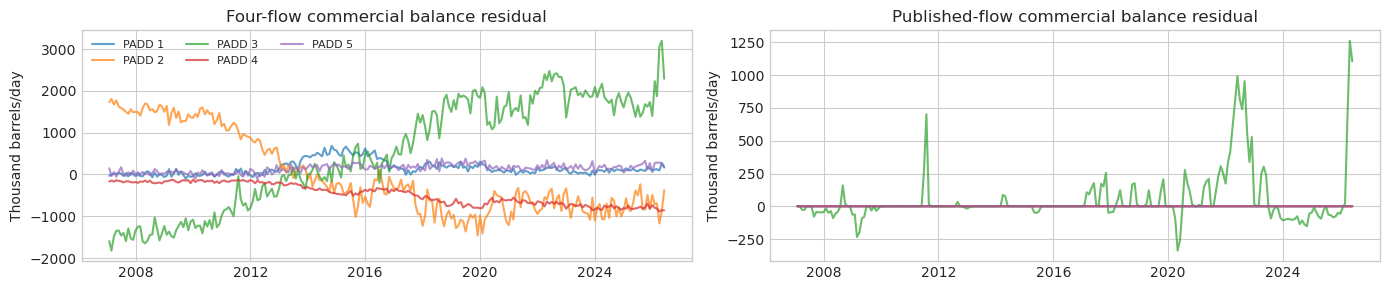

In [6]:
# Compare residuals from the four-flow shortcut and the full published-flow
# balance. The >2 kbd exception threshold is a diagnostic display rule, not a
# training filter or a rule for forcing the commercial residual to zero.

audit=panel.groupby('padd').agg(
    incomplete_balance_mae_kbd=('five_term_residual_kbd',lambda s:s.abs().mean()),
    complete_balance_mae_kbd=('accounting_residual_kbd',lambda s:s.abs().mean()),
    max_complete_residual_kbd=('accounting_residual_kbd',lambda s:s.abs().max()))
display(audit)
exceptions=panel[panel.accounting_residual_kbd.abs()>2]
display(exceptions[['month','padd','accounting_residual_kbd']])
fig,axes=plt.subplots(1,2,figsize=(14,3))
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month,g.five_term_residual_kbd,label=f'PADD {p}',alpha=.7)
    axes[1].plot(g.month,g.accounting_residual_kbd,label=f'PADD {p}',alpha=.7)
axes[0].set(title='Four-flow commercial balance residual',ylabel='Thousand barrels/day')
axes[1].set(title='Published-flow commercial balance residual',ylabel='Thousand barrels/day')
axes[0].legend(ncol=3,fontsize=8);plt.tight_layout();plt.show()

Changes in commercial stocks may not match EIA’s broader crude-flow balance. The difference is shown as a daily residual, and the model does not create a missing flow to make the numbers match.

## 4. Forecast timing and limits of the evaluation

Each row predicts stocks at the end of month **t**. It uses stock and flow data available through the previous month, **t−1**, along with the month being forecast. Inputs are earlier stock levels, latest stock change, previous-month flows, and seasonal patterns when used. (Actual flows from the month being predicted are never used as inputs.)

The flow model uses the latest 60 (random number choice) observations. It identifies a trend and seasonal pattern for each month of the year.

The model forecasts refinery utilization by dividing daily crude input by available refinery capacity.

For each PADD, refinery capacity is kept at the latest value known when the forecast begins. This rule also applies to historical tests. Actual crude input can sometimes be slightly higher than the reported capacity, but the forecast does not assume that utilization will exceed 100%.

This evaluation uses the latest revised historical EIA data. It does not have the data that would have been available when each forecast was made. This is an issue because the EIA publishes monthly data with a delay and may revise earlier values.

The final 24 months are not used to choose models or settings..

In [7]:
# Build a trend in years plus 11 calendar-month indicators. January is the
# reference month represented by the regression intercept.
def seasonal_design(months, origin):
    dates = pd.DatetimeIndex(months)
    trend = ((dates.year - origin.year) * 12 + dates.month - origin.month).to_numpy() / 12
    return np.column_stack([trend] + [(dates.month == m).astype(float) for m in range(2, 13)])


# Use only the supplied origin history. The last 60 non-COVID observations may
# span more than 60 calendar months because excluded months are skipped.
def forecast_flows(history, months):
    """Forecast daily flows and crude-input/capacity ratio from origin history."""
    train = history.loc[outside_covid(history.month)].tail(60)
    # For crude, model refinery utilization instead of demand directly, then recover
    # refinery input using utilization times capacity known at the forecast origin.
    targets = [c for c in FLOWS if c != 'demand_kbd'] + ['utilization_ratio']
    model = LinearRegression().fit(
        seasonal_design(train.month, train.month.iloc[0]), train[targets])
    result = pd.DataFrame(model.predict(seasonal_design(months, train.month.iloc[0])),
                          columns=targets, index=pd.DatetimeIndex(months))
    # Clip forecast utilization to 0-100% and freeze capacity at its last known
    # value; future actual capacity must not enter a historical forecast.
    result['utilization_ratio'] = result.utilization_ratio.clip(0, 1)
    result['cdu_capacity_kbd'] = float(history.cdu_capacity_kbd.iloc[-1])
    result['demand_kbd'] = result.utilization_ratio * result.cdu_capacity_kbd
    for c in ['production_kbd', 'imports_kbd', 'exports_kbd', 'direct_use_kbd']:
        result[c] = result[c].clip(lower=0)
    return result[FLOWS + ['cdu_capacity_kbd', 'utilization_ratio']]

In [8]:
# Build target-month inputs from history ending one month earlier. History must
# be sorted, continuous, and contain at least 12 monthly observations.
def feature_row(history, month):
    last = history.iloc[-1]
    # Use prior stock, year-ago stock, and the latest stock change. Sine/cosine encode
    # annual seasonality smoothly across the December/January boundary.
    row = {'stock_lag1': last.stock_kb, 'stock_lag12': history.iloc[-12].stock_kb,
           'change_lag1': last.stock_kb - history.iloc[-2].stock_kb,
           'sin_month': np.sin(2*np.pi*month.month/12), 'cos_month': np.cos(2*np.pi*month.month/12)}
    # Calculate observed changes before filtering; omit any change whose current
    # or previous stock observation falls inside the excluded COVID period.
    changes = history.set_index('month').stock_kb.diff()
    clean = outside_covid(changes.index) & outside_covid(changes.index - pd.DateOffset(months=1))
    changes = changes.loc[clean].tail(60)
    # Average recent eligible changes for the target calendar month; use zero
    # if that month has no usable historical changes.
    seasonal = changes[changes.index.month == month.month].dropna()
    row['seasonal_change'] = float(seasonal.mean()) if len(seasonal) else 0.0
    # Compare the latest stock with earlier same-calendar-month stock levels,
    # excluding the latest observation from its own reference average.
    normal_history = history.iloc[:-1].loc[lambda f: outside_covid(f.month)].tail(60)
    normal = normal_history[normal_history.month.dt.month.eq(last.month.month)].stock_kb
    row['stock_seasonal_gap'] = float(last.stock_kb - normal.mean()) if len(normal) else 0.0
    # Pre-sign prior-month flows so nonnegative regression coefficients retain the
    # supply-versus-demand direction in the constrained model.
    row.update({'lag_' + c: last[c] * sign for c, sign in zip(FLOWS, SIGNS)})
    return row


# Create labeled rows after a 12-month warm-up. Rebuild each feature vector and
# flow-identity benchmark using only history preceding that row's target month.
def supervised(history):
    rows = []
    for i in range(12, len(history)):
        # Keep the target separate: its stock supplies actual_kb/delta_kb only. Actual
        # target-month flows must not become inputs to a prediction of that month.
        past, current = history.iloc[:i], history.iloc[i]
        row = feature_row(past, current.month)
        flow = forecast_flows(past, [current.month]).iloc[0]
        row.update(month=current.month, origin_month=past.month.iloc[-1],
                   actual_kb=current.stock_kb, delta_kb=current.stock_kb-past.stock_kb.iloc[-1],
                   forecast_flow_identity=max(0.0, past.stock_kb.iloc[-1] + flow[FLOWS].to_numpy() @ SIGNS * current.month.days_in_month))
        rows.append(row)
    return pd.DataFrame(rows)

In [9]:
# Inspect a few supervised rows to make the forecast origin/target alignment
# concrete. Each origin must precede its target; actual_kb is an outcome only.

example=supervised(panel[panel.padd.eq(3)].reset_index(drop=True))
display(example[['origin_month','month','stock_lag1','lag_production_kbd','lag_demand_kbd',
                 'forecast_flow_identity','actual_kb']].tail())
assert (example.origin_month<example.month).all()

,origin_month,month,stock_lag1,lag_production_kbd,lag_demand_kbd,forecast_flow_identity,actual_kb
217,2026-01-01,2026-02-01,"224,301.00","9,849.23","-8,907.68","243,036.16","249,711.00"
218,2026-02-01,2026-03-01,"249,711.00","10,211.14","-8,733.11","260,609.30","260,536.00"
219,2026-03-01,2026-04-01,"260,536.00","10,190.74","-9,276.29","269,918.32","258,758.00"
220,2026-04-01,2026-05-01,"258,758.00","10,439.80","-9,360.27","261,554.91","244,403.00"
221,2026-05-01,2026-06-01,"244,403.00","10,221.13","-9,556.10","240,283.49","233,275.00"


### How to read the model results

**Mean absolute error (MAE)** is the average size of a forecast miss, in thousand barrels. **Root Mean Squared Error (RMSE)** gives more weight to large misses. **R²** compares errors with variation in actual stocks; a negative value means errors exceed that variation benchmark.

A **recursive forecast** projects a full year one month at a time, feeding each predicted stock into the next month. (This can cause errors to become large)

## 5. Seventeen candidate models with grid-searched settings

The models use earlier stock levels, stock changes, crude flows, and—in some cases—the calendar month to predict the next inventory build or draw. A separate model is fitted for each PADD. (Note: The number of models tried is for fun to use some of the material I have learned in school.)

| Model | Technical description |
|---|---|
| Unchanged stocks (persistence) | Uses the previous month’s stock level as the forecast. This is the main benchmark and has no fitted parameters. |
| Same month last year | Uses the stock level from 12 months earlier. This is a seasonal benchmark with no fitted parameters. |
| Seasonal change | Adds the historical average build or draw for the forecast month to the latest stock level. |
| Flow balance | Forecasts supply and disposition flows, calculates their net balance, and converts the expected monthly build or draw into a stock forecast. |
| Constrained regression | Uses nonnegative linear regression to predict the stock level from prior stocks and signed flow inputs. Flow signs are set in advance so that supply and disposition enter in the intended direction. |
| Ridge regression | Uses standardized linear regression to predict the stock change. An L2 penalty shrinks large coefficients and reduces sensitivity to correlated inputs and historical noise. |
| Seasonal ridge | Extends ridge regression with sine and cosine variables representing the annual seasonal cycle. |
| Polynomial ridge | Expands the inputs with polynomial terms, allowing curved relationships and interactions. Ridge regularization limits the additional model complexity. |
| Spline ridge | Represents each input with piecewise polynomial basis functions joined at selected knots. This allows smooth nonlinear relationships while ridge regularization controls overfitting. |
| Random forest | Fits many decision trees to different samples of the data and averages their predictions. It can represent nonlinear relationships and interactions without specifying them in advance. |
| XGBoost | Builds decision trees sequentially. Each new tree focuses on reducing errors left by the earlier trees, with regularization and learning-rate controls to limit overfitting. |
| Neural network | Uses one or more hidden layers to learn nonlinear combinations of the inputs. Input and target scaling improve fitting, while a penalty limits overly large model weights. |
| Five-year rolling ridge | Fits the seasonal ridge model using only the latest 60 eligible observations. This gives more weight to recent market relationships by excluding older training data. |
| Damped ridge | Uses the seasonal ridge prediction but reduces the predicted build or draw by half. This produces a more conservative forecast. |
| Ensemble | Combines predictions from seasonal ridge, random forest, and XGBoost using a weighted average. The model searches over several possible weight combinations. |
| Seasonal-departure regression | Starts with the typical build or draw for that calendar month. Ridge regression then predicts how the actual change may differ based on inventory tightness and earlier flows. |
| Robust regression | Uses Huber regression to predict the stock change. It behaves like ordinary regression for typical errors but reduces the influence of unusually large errors. |

Model settings are tested across ten time-ordered validation periods. For each period, the model is fitted using only earlier observations and then tested on later observations. The settings with the lowest average absolute stock error are selected.

The final two years are kept out of model and parameter selection. They are used later as a separate performance check. Simple and complex models are judged by the same error measure, so a complex model is chosen only if it performs better.

The fitted relationships show how stocks and flows moved together in the historical data. A regression coefficient does not prove that adding one barrel of supply directly causes stocks to rise by that amount.

The best model for a one-month forecast is selected separately from the best model for a twelve-month recursive forecast. This allows different methods to be used for short- and long-range forecasting.

### Exact model definitions

These constants list the inputs used by each model. `estimator` defines the models and their settings. `fit` decides whether a model predicts the stock level or the stock change. `predict` turns predicted changes into stock levels and also produces the simple benchmark forecasts.

In [10]:
# Baselines carry stocks forward, repeat year-ago stocks, add a seasonal change,
# or accumulate forecast net flows; none needs a fitted stock estimator.
BASELINES = ['persistence', 'seasonal_naive', 'seasonal_change', 'forecast_flow_identity']
# Candidates share forecast timing and evaluation. Names ending in '_change'
# model stock increments, while constrained_level models inventory levels.
LEARNED = ['constrained_level', 'ridge_change', 'seasonal_ridge_change',
           'polynomial_ridge_change', 'spline_ridge_change', 'random_forest_change',
           'xgboost_change', 'neural_network_change', 'rolling_ridge_change',
           'damped_ridge_change', 'ensemble_change']
LEARNED += ['seasonal_residual_change', 'huber_change']
MODELS = BASELINES + LEARNED
BASE_FEATURES = ['stock_lag1', 'stock_lag12', 'change_lag1'] + ['lag_' + c for c in FLOWS]
FEATURES = BASE_FEATURES + ['sin_month', 'cos_month']

In [11]:
# Select predictor columns explicitly. actual_kb and delta_kb are labels and
# must never enter the estimator's input matrix.
def columns(name):
    if name == 'seasonal_residual_change':
        return FEATURES + ['stock_seasonal_gap', 'seasonal_change']
    if name == 'constrained_level':
        return ['stock_lag1'] + ['lag_' + c for c in FLOWS]
    if name == 'ridge_change':
        return BASE_FEATURES
    return FEATURES


# Return an unfitted candidate. Pipeline transformations are learned inside each
# fit, so test observations cannot influence scaling or spline preparation.
def estimator(name):
    if name == 'seasonal_residual_change':
        # Standardize predictors before L2-regularized regression. Larger alpha shrinks
        # coefficients more strongly; grid search overrides these starting defaults.
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'huber_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            # Huber loss reduces outlier influence; the surrounding target transformer
            # scales the response and reverses that scaling when predicting.
            HuberRegressor(max_iter=1000)), transformer=StandardScaler())
    if name == 'constrained_level':
        # Constrain coefficients, not the intercept, to be nonnegative. Pre-signed demand
        # features therefore contribute negatively without imposing a full flow identity.
        return LinearRegression(positive=True)
    if name in ['ridge_change', 'seasonal_ridge_change', 'rolling_ridge_change', 'damped_ridge_change']:
        # Standardize predictors before L2-regularized regression. Larger alpha shrinks
        # coefficients more strongly; grid search overrides these starting defaults.
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'polynomial_ridge_change':
        # Expand predictors with powers/interactions, rescale, and regularize to control
        # flexibility. The regression supplies the intercept, so no bias column is needed.
        return make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                             StandardScaler(), Ridge(alpha=1000))
    if name == 'spline_ridge_change':
        # Represent each feature using smooth piecewise-polynomial basis functions;
        # linear extrapolation controls behavior outside its observed training range.
        return make_pipeline(SplineTransformer(n_knots=4, degree=2, extrapolation='linear'),
                             StandardScaler(), Ridge(alpha=100))
    if name == 'random_forest_change':
        # Average resampled decision trees. Depth and minimum leaf size limit complexity;
        # the fixed seed makes randomized fitting reproducible.
        return RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12,
                                     max_features=0.8, n_jobs=1, random_state=42)
    if name == 'xgboost_change':
        # Boost shallow trees sequentially. Learning rate, regularization, and row/column
        # subsampling control how aggressively the ensemble fits remaining residuals.
        return XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03,
            min_child_weight=12, reg_lambda=30, subsample=0.8, colsample_bytree=0.8,
            n_jobs=1, random_state=42, objective='reg:squarederror')
    if name == 'neural_network_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            # Fit a small neural network with LBFGS on scaled inputs and a scaled target.
            # Alpha penalizes weights, and the random seed fixes initialization.
            MLPRegressor(hidden_layer_sizes=(16,), alpha=10, solver='lbfgs',
                         max_iter=3000, random_state=42)), transformer=StandardScaler())
    if name == 'ensemble_change':
        # Average seasonal ridge, random forest, and XGBoost predictions. The tuning
        # grid varies their relative weights.
        return VotingRegressor([(n, estimator(n)) for n in
            ['seasonal_ridge_change', 'random_forest_change', 'xgboost_change']])
    raise ValueError(name)

In [12]:
# Return (estimator, warning_text). Baselines return None because predict computes
# them directly; learned candidates filter training dates before fitting.
def fit(name, train, params=None):
    if name in BASELINES:
        return None, ''
    train = training_rows(train)
    model = estimator(name)
    if params:
        model.set_params(**params)
    if name == 'rolling_ridge_change':
        train = train.tail(60)
    # Choose inventory level or monthly change as response, both in thousand barrels.
    target = 'actual_kb' if name == 'constrained_level' else 'delta_kb'
    # Match the search's numerical settings, including neural-network refits.
    from threadpoolctl import threadpool_limits
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1):
        warnings.simplefilter('always', ConvergenceWarning)
        # Fit the seasonal-residual candidate to departures from normal seasonal change;
        # predict reconstructs the seasonal component before converting to stock levels.
        values = train[target] - train.seasonal_change if name == 'seasonal_residual_change' else train[target]
        model.fit(train[columns(name)], values)
    return model, '; '.join(str(w.message) for w in caught)


# Return stock levels in kb for every candidate, including change-based models.
# Use identical reconstruction and flooring rules during tuning and forecasting.
def predict(name, model, frame):
    if name == 'persistence':
        return frame.stock_lag1.to_numpy()
    if name == 'seasonal_naive':
        return frame.stock_lag12.to_numpy()
    if name == 'seasonal_change':
        return np.maximum(0, frame.stock_lag1.to_numpy() + frame.seasonal_change.to_numpy())
    if name == 'forecast_flow_identity':
        return frame.forecast_flow_identity.to_numpy()
    prediction = model.predict(frame[columns(name)])
    if name == 'seasonal_residual_change':
        prediction += frame.seasonal_change.to_numpy()
    # Halve the estimated change to shrink the forecast toward unchanged stocks.
    if name == 'damped_ridge_change':
        prediction *= 0.5
    # Add the predicted increment to prior stock to recover an inventory level.
    if name != 'constrained_level':
        prediction += frame.stock_lag1.to_numpy()
    # Prevent a learned model from producing a negative final stock level.
    return np.maximum(prediction, 0)

In [13]:
# Enumerate tunable combinations. Double underscores address nested pipeline
# parameters; an empty grid indicates a candidate with no parameter search.
def parameter_grid(name):
    """Conventional, compact Cartesian grids; structural baselines stay fixed."""
    if name == 'seasonal_residual_change':
        return {'ridge__alpha': [0.1, 1, 10, 100, 1000]}
    if name == 'huber_change':
        return {'regressor__huberregressor__epsilon': [1.35, 1.75],
                'regressor__huberregressor__alpha': [0.01, 1, 10]}
    if name in ['ridge_change', 'seasonal_ridge_change', 'rolling_ridge_change', 'damped_ridge_change']:
        return {'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    if name == 'polynomial_ridge_change':
        return {'polynomialfeatures__degree': [1, 2], 'ridge__alpha': [1, 10, 100, 1000]}
    if name == 'spline_ridge_change':
        return {'splinetransformer__n_knots': [3, 5, 7],
                'splinetransformer__degree': [2, 3], 'ridge__alpha': [1, 100, 1000]}
    if name == 'random_forest_change':
        return {'n_estimators': [100, 200], 'max_depth': [3, 5, None],
                'min_samples_leaf': [5, 12]}
    if name == 'xgboost_change':
        return {'n_estimators': [100, 200], 'max_depth': [2, 4],
                'learning_rate': [0.01, 0.05, 0.1], 'reg_lambda': [1, 30]}
    if name == 'neural_network_change':
        return {'regressor__mlpregressor__hidden_layer_sizes': [(16,), (32,), (32, 16)],
                'regressor__mlpregressor__alpha': [0.01, 1, 10]}
    if name == 'ensemble_change':
        return {'weights': [(1, 1, 1), (2, 1, 1), (1, 2, 1), (1, 1, 2)]}
    return {}


# Adapt candidates to sklearn's cloning/search interface. Score reconstructed
# stock levels, including seasonal adjustments, damping, and the zero floor.
class StockRegressor(RegressorMixin, BaseEstimator):
    """Score the actual stock forecast, including damping, floor and rolling fit."""
    def __init__(self, name, model):
        self.name = name
        self.model = model

    def fit(self, X, y):
        from sklearn.base import clone
        # The sliced frame carries labels and dates for eligibility filtering; y is
        # accepted for sklearn compatibility, while the response is selected below.
        eligible = training_rows(X)
        train = eligible.tail(60) if self.name == 'rolling_ridge_change' else eligible
        target = train.actual_kb if self.name == 'constrained_level' else train.delta_kb
        if self.name == 'seasonal_residual_change':
            target = target - train.seasonal_change
        # Clone an unfitted candidate for each fold so fitted state cannot leak across
        # search trials. A trailing underscore conventionally marks fitted attributes.
        self.model_ = clone(self.model).fit(train[columns(self.name)], target)
        return self

    def predict(self, X):
        return predict(self.name, self.model_, X)


# Search only the supplied past window; return parameters, all candidate/fold
# scores, and convergence warnings. The chosen estimator is fitted separately.
def tune(name, train, folds=10, jobs=8, splits=None):
    """Search only the supplied past history; retain every candidate and fold score."""
    grid = parameter_grid(name)
    if not grid:
        return {}, pd.DataFrame(), ''
    cv = splits if splits is not None else validation_splits(train, folds)
    # Maximize negative MAE, equivalent to minimizing stock error. model__ reaches
    # the candidate inside StockRegressor; refit=False avoids an unused final fit.
    search = GridSearchCV(StockRegressor(name, estimator(name)),
        {'model__' + key: value for key, value in grid.items()},
        scoring='neg_mean_absolute_error', cv=cv, n_jobs=jobs,
        refit=False, error_score='raise', return_train_score=True)
    # Threads keep warnings in this process; native numerical threads are capped.
    from joblib import parallel_backend
    from threadpoolctl import threadpool_limits
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1), parallel_backend('threading'):
        warnings.simplefilter('always', ConvergenceWarning)
        search.fit(train, train.actual_kb)
    results = pd.DataFrame(search.cv_results_)
    results['params'] = results.params.map(lambda p: json.dumps({k.removeprefix('model__'): v for k,v in p.items()}, sort_keys=True))
    # Reverse sklearn's negative-score convention to report positive MAE.
    results['mean_test_mae_kb'] = -results.mean_test_score
    # Remove the wrapper prefix so fit() can set parameters on the candidate itself.
    params = {k.removeprefix('model__'): v for k,v in search.best_params_.items()}
    warning = '; '.join(sorted({str(w.message) for w in caught}))
    return params, results, warning

In [14]:
# Show each candidate's search space before running the experiment; nested
# parameter names identify the relevant estimator or pipeline transformation.

display(pd.DataFrame([{'model':name,'param_grid':parameter_grid(name)} for name in LEARNED]))

,model,param_grid
0,constrained_level,{}
1,ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
2,seasonal_ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
3,polynomial_ridge_change,"{'polynomialfeatures__degree': [1, 2], 'ridge_..."
4,spline_ridge_change,"{'splinetransformer__n_knots': [3, 5, 7], 'spl..."
5,random_forest_change,"{'n_estimators': [100, 200], 'max_depth': [3, ..."
6,xgboost_change,"{'n_estimators': [100, 200], 'max_depth': [2, ..."
7,neural_network_change,{'regressor__mlpregressor__hidden_layer_sizes'...
8,rolling_ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
9,damped_ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"


### How errors and national totals are calculated

MAE averages absolute errors; RMSE squares errors before averaging and taking a square root; R² compares squared errors with variation around the evaluation sample mean.

`aggregate` checks five distinct PADDs for every key before summing. Regional MAEs are not added to obtain national MAE.

In [15]:
# MAE and RMSE are in kb; RMSE weights large misses more. R-squared is unitless
# and may be negative when errors exceed the actual sample's mean-only benchmark.
def score(actual, predicted):
    return {'mae_kb': mean_absolute_error(actual, predicted),
            'rmse_kb': mean_squared_error(actual, predicted)**0.5,
            'r2': r2_score(actual, predicted), 'n': len(actual)}


# Require one row for every PADD in each group before summing additive columns.
# Compute national errors after summation; regional forecast errors can offset.
def aggregate(frame, keys, additive):
    """Reject partial U.S. totals instead of silently summing fewer than five PADDs."""
    if frame.duplicated(keys + ['padd']).any():
        raise ValueError('Duplicate PADD rows in aggregation')
    if not frame.groupby(keys).padd.nunique().eq(5).all():
        raise ValueError('U.S. aggregation requires all five PADDs')
    return frame.groupby(keys, as_index=False)[additive].sum(min_count=5)


# Score each group, expanding either a scalar or tuple group key into the named
# key columns of the resulting metrics table.
def metric_table(predictions, keys):
    return pd.DataFrame([{**dict(zip(keys, k if isinstance(k, tuple) else (k,))),
        **score(g.actual_kb, g.predicted_kb)} for k,g in predictions.groupby(keys)])

In [16]:
# Inspect the candidate roster and example estimator configurations. The count
# assertion guards the expected 17-model comparison; it does not evaluate accuracy.

assert len(MODELS)==17
print('Complete constrained features:',columns('constrained_level'))
print(estimator('neural_network_change'))
print(estimator('ensemble_change'))

Complete constrained features: ['stock_lag1', 'lag_production_kbd', 'lag_demand_kbd', 'lag_imports_kbd', 'lag_exports_kbd', 'lag_net_receipts_kbd', 'lag_adjustments_kbd', 'lag_transfers_kbd', 'lag_direct_use_kbd']
TransformedTargetRegressor(regressor=Pipeline(steps=[('standardscaler',
                                                      StandardScaler()),
                                                     ('mlpregressor',
                                                      MLPRegressor(alpha=10,
                                                                   hidden_layer_sizes=(16,),
                                                                   max_iter=3000,
                                                                   random_state=42,
                                                                   solver='lbfgs'))]),
                           transformer=StandardScaler())
VotingRegressor(estimators=[('seasonal_ridge_change',
                             Pipeline

## 6. Run the full experiment

The following cells train and test all candidate models using the saved data. The code also searches for the best model parameters at each starting point (first date for forecast).

**One-month forecasts:** The model uses ten fold CV. In each fold, it trains on earlier data and tests the following 12 eligible months. Model settings stay fixed during that round, while each forecast uses the latest available previous-month data. After adding the five regional forecasts together, the model with the lowest national average error is selected.

**Twelve-month forecasts:** All 17 models are tested across six separate one-year periods. Each model forecasts the full 12 months without updating predicted stocks with actual results. The model with the lowest national average error across all 72 forecast months is selected separately for long-term forecasting.

In [17]:
# Choose each PADD's one-step candidate on development data, evaluate the fixed
# choices on the last 24 months, then refit winners for the live outlook.
def evaluate(samples, folds=10, holdout=24, jobs=8):
    """Choose models only on development CV; score untouched final 24 months."""
    predictions, fold_metrics, selections, fitted, warning_rows = [], [], [], {}, []
    best_parameters, searches = {}, []
    for padd, frame in samples.items():
        # Reserve the final holdout rows before any tuning or candidate selection.
        development = frame.iloc[:-holdout]
        if len(development) - folds*12 < 36:
            raise ValueError('Need >=36 initial training months plus 10 annual folds and holdout')
        splits = validation_splits(development, folds, test_size=12)
        for name in MODELS:
            params, results, warning = tune(name, development, folds, jobs, splits)
            best_parameters[padd, name] = params
            if not results.empty:
                searches.append(results.assign(padd=padd, model=name, stage='development',
                    train_end=development.month.max()))
                print(f'PADD {padd} {name}: grid MAE {results.mean_test_mae_kb.min():,.1f}; {params}', flush=True)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='grid_search', warning=warning))
            # Reuse tuning folds for development diagnostics; these are selection scores,
            # not independent nested-CV estimates of future generalization.
            for fold, (tr, te) in enumerate(splits, 1):
                train, test = training_rows(development.iloc[tr]), development.iloc[te]
                model, warning = fit(name, train, params)
                pred = predict(name, model, test)
                fold_metrics.append(dict(padd=padd, model=name, fold=fold,
                    train_end=train.month.max(), test_start=test.month.min(), test_end=test.month.max(),
                    train_mae_kb=mean_absolute_error(train.actual_kb, predict(name, model, train)),
                    **score(test.actual_kb, pred)))
                output = test[['month', 'origin_month', 'actual_kb']].copy()
                output['predicted_kb'], output['padd'], output['model'] = pred, padd, name
                output['split'], output['fold'] = 'cv', fold
                predictions.append(output)
                if warning:
                    warning_rows.append(dict(padd=padd, model=name, stage=f'cv_{fold}', warning=warning))
        current = pd.concat(predictions, ignore_index=True)
        current = current[current.padd.eq(padd)]
        # Pool absolute development errors for this PADD across folds and select
        # the lowest mean; no holdout observations enter this comparison.
        losses = current.assign(error=lambda x: abs(x.actual_kb-x.predicted_kb)).groupby('model').error.mean()
        winner = losses.idxmin()
        selections.append(dict(padd=padd, selected_model=winner, cv_mae_kb=losses[winner]))
        for name in MODELS:
            model, warning = fit(name, development, best_parameters[padd, name])
            # This is one-step evaluation: each row uses actual prior-month inputs, while
            # estimator parameters remain fitted on development data for the entire block.
            test = frame.iloc[-holdout:]
            output = test[['month', 'origin_month', 'actual_kb']].copy()
            output['predicted_kb'] = predict(name, model, test)
            output['padd'], output['model'], output['split'], output['fold'] = padd, name, 'holdout', 0
            predictions.append(output)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='holdout', warning=warning))
        # Refit the already chosen winner on all eligible history for future use.
        # This final estimator is separate from the one that produced holdout scores.
        final, warning = fit(winner, frame, best_parameters[padd, winner])
        fitted[padd] = {'name': winner, 'estimator': final}
        if warning:
            warning_rows.append(dict(padd=padd, model=winner, stage='final', warning=warning))
        print(f'PADD {padd}: selected {winner}; CV MAE {losses[winner]:,.1f} kb', flush=True)
    return (pd.concat(predictions, ignore_index=True), pd.DataFrame(fold_metrics),
            pd.DataFrame(selections), fitted,
            pd.DataFrame(warning_rows, columns=['padd','model','stage','warning']),
            best_parameters, pd.concat(searches, ignore_index=True))

In [18]:
# Produce a recursive path per district plus national sums. After the origin,
# features depend on predicted stocks/flows, not future actual observations.
def forecast(history, fitted, horizon=12):
    all_paths = []
    for p, state in fitted.items():
        past = history[history.padd.eq(p)].sort_values('month').copy()
        origin = past.month.iloc[-1]
        months = pd.date_range(origin + pd.offsets.MonthBegin(), periods=horizon, freq='MS')
        # Forecast the full flow path once at the origin; do not refit flows each step
        # using synthetic observations appended to the stock path.
        flows = forecast_flows(past, months)
        # Track a separate raw flow-identity path initialized at the last observed stock.
        identity_stock = past.stock_kb.iloc[-1]
        for h, month in enumerate(months, 1):
            previous = past.stock_kb.iloc[-1]
            flow = flows.loc[month]
            balance = flow[FLOWS].to_numpy() @ SIGNS
            # Crude balances are daily rates; multiply by target-month days to obtain
            # the monthly stock increment in kb.
            volume = balance * month.days_in_month
            # At longer horizons, past contains earlier predicted rows. This is the recursive
            # feedback through which forecast errors can propagate along the path.
            features = feature_row(past, month)
            features['forecast_flow_identity'] = max(0.0, previous + volume)
            stock = float(predict(state['name'], state['estimator'], pd.DataFrame([features]))[0])
            # Keep the raw flow accumulation unclipped so impossible inventory paths remain
            # visible; it can diverge from the statistical stock forecast.
            identity_stock += volume
            row = dict(month=month, origin_month=origin, horizon=h, padd=p,
                padd_name=PADD_NAMES[p], model=state['name'], stock_kb=stock,
                previous_stock_kb=previous, stock_change_kb=stock-previous,
                identity_stock_unclipped_kb=identity_stock, balance_kbd=balance,
                # Express statistical stock change minus forecast net supply as a daily
                # rate. This discrepancy is not an extra observed EIA adjustment.
                model_reconciliation_kbd=(stock-previous)/month.days_in_month-balance,
                supply_kbd=flow.production_kbd+flow.imports_kbd+flow.net_receipts_kbd+flow.adjustments_kbd+flow.transfers_kbd,
                total_demand_kbd=flow.demand_kbd+flow.exports_kbd+flow.direct_use_kbd, **flow.to_dict())
            all_paths.append(row)
            # Append the predicted row so the next month uses this stock and these flows
            # as its most recent history, without seeing future actual values.
            past = pd.concat([past, pd.DataFrame([row])], ignore_index=True)
    regional = pd.DataFrame(all_paths)
    sums = FLOWS + ['stock_kb', 'previous_stock_kb','stock_change_kb', 'identity_stock_unclipped_kb',
                   'balance_kbd','model_reconciliation_kbd','supply_kbd','total_demand_kbd','cdu_capacity_kbd']
    national = aggregate(regional, ['month','origin_month','horizon'], sums)
    # National utilization is total refinery input divided by total capacity,
    # not a sum or unweighted average of regional utilization ratios.
    national['utilization_ratio'] = national.demand_kbd / national.cdu_capacity_kbd
    return regional, national

In [19]:
# Run controls: use ten expanding validation folds and eight search workers.
# The worker count controls parallel grid trials; numerical threads are capped
# inside fitting to avoid multiplying the number of active CPU threads.

data_dir=HERE/'data'
output_dir=OUTPUT
folds=10
jobs=8

In [ ]:
output = Path(output_dir)
# Build chronological supervised samples separately for all five districts,
# then run the full development search, one-step holdout evaluation, and refits.
# This is a computationally expensive cell; progress and warnings are retained.
output.mkdir(parents=True, exist_ok=True)
panel = load_panel(data_dir)
histories = {p: panel[panel.padd.eq(p)].reset_index(drop=True) for p in PADD_NAMES}
samples = {p: supervised(history) for p,history in histories.items()}
predictions, fold_metrics, selection, fitted, fit_warnings, best_parameters, grid_results = evaluate(samples, folds, jobs=jobs)

display(fold_metrics.groupby('model').agg(folds=('fold','count'),test_mae_kb=('mae_kb','mean')))
display(selection)

In [ ]:
# For crude, compare the mixture of regional winners with each common model
# family on national development MAE. Keep regional winners for audit, but deploy
# the model with the smallest national error without using holdout scores.

# Label the development-selected regional forecasts as a combined model while
# retaining every original candidate's predictions for comparison.
selected = predictions.merge(selection[['padd','selected_model']], on='padd')
selected = selected[selected.model.eq(selected.selected_model)].copy()
selected['model'] = 'selected_padd_models'
combined = pd.concat([predictions, selected[predictions.columns]], ignore_index=True)
us_predictions = aggregate(combined, ['month','origin_month','model','split','fold'], ['actual_kb','predicted_kb'])
# Choose the aggregation model on development predictions only. A single
# common model family can outperform the mix of regional winners nationally.
one_month_model_scores = metric_table(us_predictions[us_predictions.split.eq('cv')], ['model'])
# Select a common-family model or the mix of PADD winners by national CV MAE.
# This extra selection is also based on development data and can be optimistic.
one_month_model = one_month_model_scores.sort_values(['mae_kb','model']).iloc[0].model
# Preserve regional-only winners before a possible national-model override.
regional_selection = selection.copy()
# When a common family wins nationally, refit that family separately for each
# PADD and update deployment labels while retaining the original comparisons.
if one_month_model != 'selected_padd_models':
    for p, frame in samples.items():
        estimator, warning = fit(one_month_model, frame, best_parameters[p, one_month_model])
        fitted[p] = {'name': one_month_model, 'estimator': estimator}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, one_month_model, 'national_model_final', warning]
    selection['selected_model'] = one_month_model
    selection['cv_mae_kb'] = [mean_absolute_error(g.actual_kb, g.predicted_kb)
        for p in selection.padd
        for g in [predictions.query("padd == @p and model == @one_month_model and split == 'cv'")]]
padd_metrics = metric_table(combined, ['padd','model','split'])
us_metrics = metric_table(us_predictions, ['model','split'])
# Generate the next month using the selected one-step estimators. The separate
# year-ahead selection below may choose a different family for the 12-month path.
one_step_regional, one_step_national = forecast(panel, fitted, horizon=1)

display(one_month_model_scores.sort_values('mae_kb'))
print('One-month model:', one_month_model)

In [ ]:
# Evaluate every candidate on six complete development-year forecast paths.
# Retune at each historical origin, sum PADD predictions, then choose the common
# year-ahead family using national MAE across all path months.

# Long-horizon model selection is a different task. Six disjoint development
# years end before the final holdout; all candidates use the actual recursive
# forecast function, without seeing any test-year observations.
development_end = samples[1].month.iloc[-25]
recursive_cv = []
for cutoff in recursive_origins(development_end):
    for name in MODELS:
        states = {}
        for p in PADD_NAMES:
            # Restrict fitting to targets observed by this simulated forecast origin.
            train = samples[p][samples[p].month.le(cutoff)]
            # Retune on this origin's history only; later development observations must not
            # inform a model used to forecast an earlier evaluation year.
            params, results, tuning_warning = tune(name, train, folds, jobs)
            if not results.empty:
                grid_results = pd.concat([grid_results, results.assign(padd=p, model=name,
                    stage='recursive_development', train_end=cutoff)], ignore_index=True)
            if tuning_warning:
                fit_warnings.loc[len(fit_warnings)] = [p, name, 'recursive_grid_search', tuning_warning]
            model, warning = fit(name, train, params)
            states[p] = {'name': name, 'estimator': model}
            if warning:
                fit_warnings.loc[len(fit_warnings)] = [p, name, 'recursive_cv', warning]
        path, _ = forecast(panel[panel.month.le(cutoff)], states)
        path = path[['padd','month','origin_month','horizon','stock_kb']].rename(columns={'stock_kb':'predicted_kb'})
        # Attach actual stocks only after forecasting, for scoring. one_to_one rejects
        # duplicate month/PADD observations that could otherwise multiply rows.
        path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
        path['model'] = name
        recursive_cv.append(path)
    print(f'Recursive development origin {cutoff.date()} complete', flush=True)
recursive_cv = pd.concat(recursive_cv, ignore_index=True)
us_recursive_cv = aggregate(recursive_cv, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
year_ahead_model_scores = metric_table(us_recursive_cv, ['model']).sort_values(['mae_kb','model'])
# Choose the lowest national development-path MAE, with model name as a stable
# tie-breaker; freeze the family before examining recursive holdout results.
year_ahead_model = year_ahead_model_scores.iloc[0].model
# Refit the selected year-ahead family on full eligible history, using parameter
# settings chosen before the holdout; then build the forward 12-month outlook.
horizon_fitted = {}
for p in PADD_NAMES:
    model, warning = fit(year_ahead_model, samples[p], best_parameters[p, year_ahead_model])
    horizon_fitted[p] = {'name': year_ahead_model, 'estimator': model}
    if warning:
        fit_warnings.loc[len(fit_warnings)] = [p, year_ahead_model, 'horizon_final', warning]
regional, national = forecast(panel, horizon_fitted)
print(f'National one-step model: {one_month_model}; 12-month model: {year_ahead_model}', flush=True)

display(year_ahead_model_scores)
print('Twelve-month model:', year_ahead_model)

In [ ]:
# Evaluate the fixed year-ahead model, recursive one-step model, and benchmarks
# at 13 monthly origins. Refit on history available at each origin using frozen
# development parameters; overlapping 12-month paths have correlated errors.

# Thirteen rolling 12-month paths lying wholly inside the final holdout.
# They overlap and are correlated; do not interpret them as 13 independent years.
recursive = []
# Move the origin forward one month at a time; each next 12 months remains
# inside the final 24-month evaluation period.
evaluation_models = list(dict.fromkeys([year_ahead_model, one_month_model, 'persistence', 'constrained_level']))
for offset in range(24, 11, -1):
    cutoff = panel.month.max() - pd.DateOffset(months=offset)
    for name in evaluation_models:
        states = {}
        for p, state in fitted.items():
            # Restrict fitting to targets observed by this simulated forecast origin.
            train = samples[p][samples[p].month.le(cutoff)]
            model, warning = fit(name, train, best_parameters[p, name])
            states[p] = {'name': name, 'estimator': model}
            if warning:
                fit_warnings.loc[len(fit_warnings)] = [p, name, 'recursive_holdout', warning]
        path, _ = forecast(panel[panel.month.le(cutoff)], states)
        path['model'] = name
        # Attach actual stocks only after forecasting, for scoring. one_to_one rejects
        # duplicate month/PADD observations that could otherwise multiply rows.
        path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], suffixes=('_forecast','_actual'), validate='one_to_one')
        path = path.rename(columns={'stock_kb_forecast':'predicted_kb','stock_kb_actual':'actual_kb'})
        recursive.append(path)
recursive = pd.concat(recursive, ignore_index=True)
us_recursive = aggregate(recursive, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])

display(metric_table(us_recursive, ['model']))

In [ ]:
# Combine regional history into national totals and show the next-month
# forecast. The latest table contains five PADD rows plus one U.S. reporting row.

# Build national historical totals from all five districts. Ratios, when needed,
# must be recomputed from their summed numerator and denominator.
us_history = aggregate(panel, ['month'], FLOWS+['stock_kb','cdu_capacity_kbd',
    'balance_kbd','accounting_residual_kbd','five_term_balance_kbd','five_term_residual_kbd'])
us_history['utilization_ratio'] = us_history.demand_kbd / us_history.cdu_capacity_kbd
# Use padd=0 as a reporting label for the U.S. total; it is not a sixth region.
latest_us = one_step_national.assign(padd=0, padd_name='United States (sum of PADDs)',
                                                   model=one_month_model)
latest = pd.concat([one_step_regional, latest_us], ignore_index=True)

display(us_history.tail(3))
display(latest[['padd','padd_name','month','stock_kb']])

In [ ]:
# Save result tables and fitted models for reporting and reuse. CSVs carry
# readable diagnostics; joblib preserves estimator state; coefficients expose
# the constrained regression's fitted relationship.

# Collect inputs, predictions, scores, selections, and audits under stable names.
# Each name becomes a CSV stem consumed by later reporting cells.
tables = {'padd_monthly_model':panel,'us_monthly_model':us_history,
    'padd_predictions':combined,'us_predictions':us_predictions,'padd_model_metrics':padd_metrics,
    'us_model_metrics':us_metrics,'fold_metrics':fold_metrics,'selected_models':selection,
    'regional_cv_winners':regional_selection, 'national_model_cv_metrics':one_month_model_scores,
    'recursive_cv_predictions':recursive_cv, 'us_recursive_cv_predictions':us_recursive_cv,
    'year_ahead_model_cv_metrics':year_ahead_model_scores,
    'padd_forecast_12m':regional,'us_forecast_12m':national,'latest_forecast':latest,
    'recursive_holdout_predictions':recursive,'us_recursive_holdout_predictions':us_recursive,
    'recursive_holdout_metrics':metric_table(recursive,['padd','model']),
    'us_recursive_horizon_metrics':metric_table(us_recursive,['horizon','model']), 'fit_warnings':fit_warnings,
    'grid_search_results':grid_results,
    'best_parameters':pd.DataFrame([{'padd':p, 'model':name, 'params':json.dumps(params, sort_keys=True)}
        for (p,name),params in best_parameters.items()])}
# Record target and origin dates plus separate fitting/evaluation eligibility
# flags so readers can inspect exactly which dates the exclusion model affects.
tables['training_sample_audit'] = pd.concat([frame[['month','origin_month']].assign(
    padd=p, training_eligible=frame.index.isin(training_rows(frame).index),
    evaluation_eligible=outside_covid(frame.month)) for p, frame in samples.items()], ignore_index=True)
# Write named result tables without pandas' row index; rerunning replaces files
# with the same names in model_output.
for name, frame in tables.items():
    frame.to_csv(output/f'{name}.csv', index=False)
# Save all final candidate estimators as well as selected models so downstream
# analysis can reproduce predictions without repeating parameter searches.
all_fitted = {}
for p, frame in samples.items():
    for name in MODELS:
        model, warning = fit(name, frame, best_parameters[p, name])
        all_fitted[p, name] = {'name': name, 'estimator': model}
joblib.dump(all_fitted, output/'all_fitted_models.joblib')
joblib.dump(fitted, output/'fitted_models.joblib')
joblib.dump(horizon_fitted, output/'fitted_horizon_models.joblib')
# Export an interpretable constrained-regression coefficient table by PADD.
# These coefficients apply to pre-signed inputs, not unsigned raw demand flows.
coefficients = []
for p, frame in samples.items():
    model, _ = fit('constrained_level', frame)
    coefficients.append({'padd':p,'intercept_kb':model.intercept_,**dict(zip(columns('constrained_level'),model.coef_))})
pd.DataFrame(coefficients).to_csv(output/'constrained_model_coefficients.csv',index=False)
pd.DataFrame(coefficients).to_csv(output/'padd_model_coefficients.csv',index=False)

print('Saved',len(tables),'result tables to',output)

In [ ]:
# Persist machine-readable run documentation alongside result tables. Source
# URLs identify provenance; versions and settings describe the actual run,
# including limitations of revised-history and point-only forecasts.

# Record scope, units, actual data dates, selection rules, limitations, and
# software versions alongside outputs for reproducibility and interpretation.
metadata = {'product':'Commercial crude oil; excludes strategic reserves',
    'covid_exclusion': {'start':'2020-03-01', 'end':'2021-03-01', 'inclusive':True,
        'method':'Exclude targets and direct lag inputs touching COVID from stock fitting; exclude COVID observations from flow fits and seasonal averages; preserve the full calendar and historical balance.',
        'evaluation':'Exclude COVID target months from development selection; full recursive development years avoid COVID; final 24 months unchanged.'},
    'stock_units':'thousand barrels at month end', 'flow_units':'thousand barrels per day',
    'equation':'S[t] = S[t-1] + days[t] * (field production[t] + imports[t] + net receipts[t] + adjustments[t] + transfers to crude[t] - refinery input[t] - exports[t] - direct use[t] + residual[t])',
    'data_start':str(panel.month.min().date()),'data_end':str(panel.month.max().date()),
    'cv':f'{folds} expanding folds, 12 eligible test months each; final 24 months excluded from selection',
    'holdout_start':str(samples[1].month.iloc[-24].date()),
    'forecast_timing':'One month after latest observed EIA month; conditional on prior monthly data being available. Current revised history, not a real-time release-vintage backtest.',
    'selection':'GridSearchCV per PADD/model on development data; PADD winners plus common-family models; lowest national development MAE chooses deployment; no holdout tuning',
    'hyperparameter_search':{'method':'GridSearchCV', 'folds':folds, 'scoring':'neg_mean_absolute_error',
        'splitter':'TimeSeriesSplit on non-COVID target dates; 12 eligible observations per development block; default block size inside recursive origins',
        'evaluation':'Development scores reuse tuning folds and are selection scores, not nested CV estimates. Final 24 months excluded from all searches.',
        'recursive':'Each development origin retunes on its past history. Holdout and final refits freeze parameters selected before holdout.'},
    'one_month_model':one_month_model,
    'year_ahead_model':year_ahead_model,
    'horizon_selection':'Lowest national MAE across six disjoint 12-month development paths, six full non-COVID development years; all 17 candidates compared',
    'flow_forecast':'Last 60 non-COVID observations, daily rates, linear trend and month fixed effects; crude run = forecast utilization ratio (clipped 0–1) times CDU capacity fixed at origin',
    'forecast_stock_floor':0, 'uncertainty':'Point forecasts only; no calibrated prediction intervals',
    'recursive_validation':'13 overlapping 12-month paths entirely in final holdout; refit at each origin; correlated errors',
    'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
                'sklearn':sklearn.__version__, 'xgboost':xgboost.__version__},
    'sources':['https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm',
               'https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp']}
(output/'model_metadata.json').write_text(json.dumps(metadata,indent=2))
# Serialize candidate definitions for inspection; repr describes configuration,
# while the joblib files above preserve actual fitted estimator state.
settings = {name: {'features': columns(name), 'estimator': repr(estimator(name)), 'param_grid':parameter_grid(name)}
            for name in LEARNED}
(output/'candidate_models.json').write_text(json.dumps(settings, indent=2))
print(us_metrics[us_metrics.split.eq('holdout')].sort_values('mae_kb').to_string(index=False))

print('Data through:',metadata['data_end'])
print('Fitting warnings:',len(fit_warnings))

In [21]:
folds=tables['fold_metrics']
# Inspect one representative model/PADD because candidates share split dates.
# Here folds is reassigned from the earlier integer setting to the metrics table.
# Assertions require training before testing and development before the holdout.
schedule=folds.query("padd==1 and model=='persistence'")[['fold','train_end','test_start','test_end','n']]
display(schedule)
assert (pd.to_datetime(schedule.train_end)<pd.to_datetime(schedule.test_start)).all()
assert pd.to_datetime(schedule.test_end).max()<pd.Timestamp(metadata['holdout_start'])

,fold,train_end,test_start,test_end,n
0,1,2013-05-01,2013-06-01,2014-05-01,12
1,2,2014-05-01,2014-06-01,2015-05-01,12
2,3,2015-05-01,2015-06-01,2016-05-01,12
3,4,2016-05-01,2016-06-01,2017-05-01,12
4,5,2017-05-01,2017-06-01,2018-05-01,12
5,6,2018-05-01,2018-06-01,2019-05-01,12
6,7,2019-05-01,2019-06-01,2021-06-01,12
7,8,2020-02-01,2021-07-01,2022-06-01,12
8,9,2022-06-01,2022-07-01,2023-06-01,12
9,10,2023-06-01,2023-07-01,2024-06-01,12


,padd,selected_model,cv_mae_kb
0,1,neural_network_change,"1,046.18"
1,2,damped_ridge_change,"4,258.24"
2,3,seasonal_change,"6,222.72"
3,4,seasonal_residual_change,738.58
4,5,spline_ridge_change,"1,646.08"


,model,mae_kb,rmse_kb,r2,n
11,seasonal_change,"8,190.01","10,450.37",0.95,120
13,seasonal_residual_change,"8,232.03","10,340.39",0.95,120
15,selected_padd_models,"8,440.53","10,453.34",0.95,120
17,xgboost_change,"9,051.74","11,385.25",0.94,120
8,random_forest_change,"9,069.75","11,319.01",0.94,120
16,spline_ridge_change,"9,318.61","11,109.33",0.95,120
2,ensemble_change,"9,384.75","11,592.29",0.94,120
7,polynomial_ridge_change,"9,903.90","12,047.77",0.94,120
4,huber_change,"10,014.32","12,339.43",0.93,120
5,neural_network_change,"10,044.17","12,263.98",0.93,120


padd,1,2,3,4,5
model,,,,,
constrained_level,1240.045865,4651.975993,8145.071871,887.980370,1720.386926
damped_ridge_change,1051.416827,4258.244729,7674.048251,785.185145,1728.138425
ensemble_change,1061.771003,4298.513596,7011.194897,773.741179,1756.959525
forecast_flow_identity,2306.896990,5010.608114,9005.547167,811.827747,2013.300947
huber_change,1077.731035,4309.789931,7591.271419,925.121139,1758.239635
neural_network_change,1046.178623,4304.095395,7646.017868,811.739484,1777.984012
persistence,1114.841667,4572.183333,7835.491667,811.408333,1886.983333
polynomial_ridge_change,1060.653663,4260.349419,7551.761366,809.733439,1773.842029
random_forest_change,1074.623520,4401.772969,6683.817144,744.434036,1763.691864


,train_mae_kb,mae_kb,test_minus_train_kb
model,,,
seasonal_residual_change,"2,365.32","2,832.42",467.11
xgboost_change,"1,468.34","2,895.26","1,426.92"
random_forest_change,"1,790.16","2,933.67","1,143.51"
seasonal_change,"2,635.56","2,942.42",306.86
ensemble_change,"2,184.63","2,980.44",795.80
spline_ridge_change,"2,251.17","3,038.35",787.18
polynomial_ridge_change,"2,457.46","3,091.27",633.80
rolling_ridge_change,"2,848.19","3,099.16",250.97
damped_ridge_change,"2,529.27","3,099.41",570.14


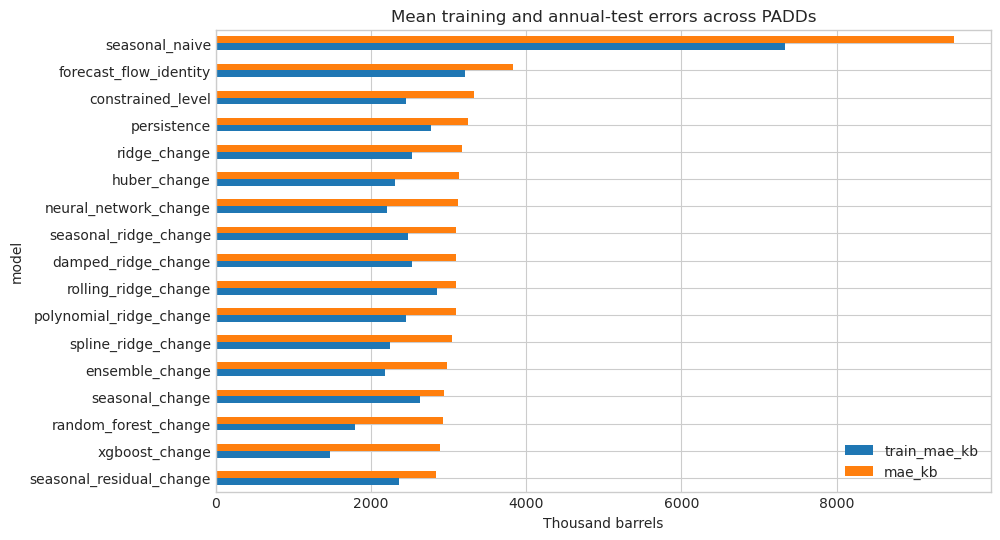

In [22]:
# Compare development MAE by candidate and district, then inspect the average
# train/test gap. A large gap suggests overfitting or a changing data regime;
# these reused selection scores are not an independent performance estimate.

display(tables['regional_cv_winners'])
display(tables['national_model_cv_metrics'].sort_values('mae_kb'))
cv=tables['padd_model_metrics'].query("split == 'cv' and model != 'selected_padd_models'")
display(cv.pivot(index='model',columns='padd',values='mae_kb').style.highlight_min(axis=0))
gaps=folds.groupby('model')[['train_mae_kb','mae_kb']].mean().sort_values('mae_kb')
# Subtract in-sample MAE from validation MAE; positive gaps mean worse
# performance on later observations than on fitted training observations.
gaps['test_minus_train_kb']=gaps.mae_kb-gaps.train_mae_kb
display(gaps)
gaps[['train_mae_kb','mae_kb']].plot.barh(figsize=(10,6),title='Mean training and annual-test errors across PADDs')
plt.xlabel('Thousand barrels');plt.show()

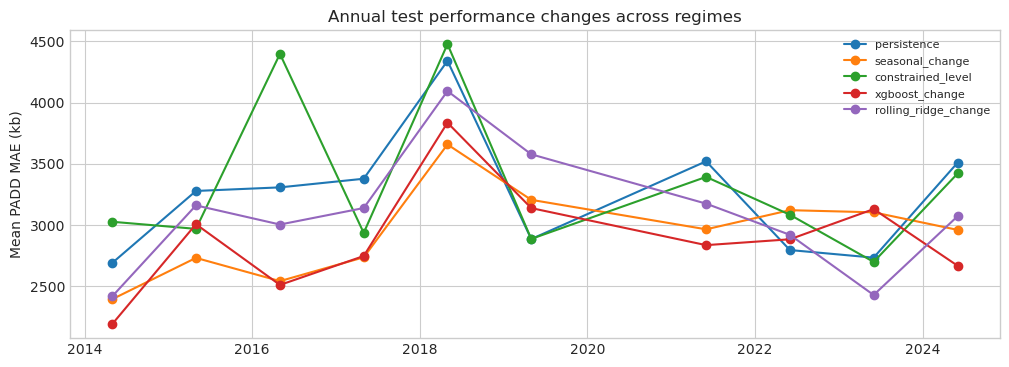

,padd,intercept_kb,stock_lag1,lag_production_kbd,lag_demand_kbd,lag_imports_kbd,lag_exports_kbd,lag_net_receipts_kbd,lag_adjustments_kbd,lag_transfers_kbd,lag_direct_use_kbd
0,1,"1,600.17",0.78,0.00,0.00,0.81,0.00,1.85,4.21,0.00,0.00
1,2,"13,336.58",0.92,13.08,12.13,9.12,6.41,10.35,6.09,10.98,0.00
2,3,"35,906.85",0.90,4.68,4.70,0.26,5.11,1.60,5.88,2.25,0.00
3,4,-439.18,0.87,5.23,1.10,5.23,2.57,3.77,5.98,11.97,0.00
4,5,"22,636.18",0.48,13.95,8.25,6.56,16.32,10.99,8.38,0.00,0.00


In [23]:
# Group validation errors by test-block endpoint to show regime variation.
# These plotted values average regional MAEs, not errors on national stock sums.
# The coefficient CSV provides a separate view of the constrained model.

fig,ax=plt.subplots(figsize=(12,4))
for name in ['persistence','seasonal_change','constrained_level','xgboost_change','rolling_ridge_change']:
    g=folds[folds.model.eq(name)].groupby('test_end').mae_kb.mean()
    ax.plot(pd.to_datetime(g.index),g.values,label=name,marker='o')
ax.set(title='Annual test performance changes across regimes',ylabel='Mean PADD MAE (kb)')
ax.legend(fontsize=8);plt.show()
display(pd.read_csv(OUTPUT/'constrained_model_coefficients.csv'))

## 8. Final one-month evaluation: July 2024–June 2026 in this run

Every learned model is refitted on the same development history before evaluation.

In [24]:
# Report final one-step national MAE for the development-selected model against
# persistence. The percentage is 100 * (1 - selected MAE / baseline MAE), so a
# negative value means deterioration. Show settings without selecting on holdout.

scores=tables['us_model_metrics'].query("split=='holdout'").sort_values('mae_kb')
display(scores)
lookup=scores.set_index('model')
selected=lookup.loc[metadata['one_month_model'],'mae_kb']
naive=lookup.loc['persistence','mae_kb']
display(Markdown(f"**Selected one-month model:** `{metadata['one_month_model']}`. National MAE is **{selected:,.0f} kb**, "
    f"versus **{naive:,.0f} kb** for persistence (**{100*(1-selected/naive):.1f}% lower**). "
    "Parameters and the model family were selected using development data only."))
with pd.option_context('display.max_colwidth',None,'display.max_rows',None):
    display(tables['best_parameters'].query("params != '{}'").reset_index(drop=True))
comparison_names = [metadata['one_month_model'], 'constrained_level', 'persistence']
display(tables['padd_model_metrics'].query("split == 'holdout' and model in @comparison_names"))

,model,split,mae_kb,rmse_kb,r2,n
23,seasonal_change,holdout,"6,781.31","9,036.61",0.44,24
31,selected_padd_models,holdout,"7,250.51","9,222.26",0.42,24
27,seasonal_residual_change,holdout,"7,339.84","9,248.33",0.42,24
17,random_forest_change,holdout,"7,862.99","9,562.93",0.38,24
33,spline_ridge_change,holdout,"8,336.50","10,238.91",0.29,24
5,ensemble_change,holdout,"8,574.38","10,287.70",0.28,24
35,xgboost_change,holdout,"8,896.36","11,143.55",0.15,24
11,neural_network_change,holdout,"9,011.52","10,533.61",0.24,24
29,seasonal_ridge_change,holdout,"9,225.54","11,265.22",0.14,24
3,damped_ridge_change,holdout,"9,436.51","11,551.45",0.09,24


**Selected one-month model:** `seasonal_change`. National MAE is **6,781 kb**, versus **9,631 kb** for persistence (**29.6% lower**). Parameters and the model family were selected using development data only.

,padd,model,params
0,1,ridge_change,"{""ridge__alpha"": 10}"
1,1,seasonal_ridge_change,"{""ridge__alpha"": 100}"
2,1,polynomial_ridge_change,"{""polynomialfeatures__degree"": 1, ""ridge__alpha"": 100}"
3,1,spline_ridge_change,"{""ridge__alpha"": 1000, ""splinetransformer__degree"": 2, ""splinetransformer__n_knots"": 3}"
4,1,random_forest_change,"{""max_depth"": 5, ""min_samples_leaf"": 12, ""n_estimators"": 200}"
5,1,xgboost_change,"{""learning_rate"": 0.01, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 1}"
6,1,neural_network_change,"{""regressor__mlpregressor__alpha"": 10, ""regressor__mlpregressor__hidden_layer_sizes"": [32, 16]}"
7,1,rolling_ridge_change,"{""ridge__alpha"": 1000}"
8,1,damped_ridge_change,"{""ridge__alpha"": 10}"
9,1,ensemble_change,"{""weights"": [2, 1, 1]}"


,padd,model,split,mae_kb,rmse_kb,r2,n
1,1,constrained_level,holdout,591.62,776.97,-0.15,24
13,1,persistence,holdout,626.88,792.38,-0.20,24
23,1,seasonal_change,holdout,579.67,772.86,-0.14,24
37,2,constrained_level,holdout,"3,333.58","4,041.28",-0.41,24
49,2,persistence,holdout,"2,859.67","3,670.33",-0.17,24
59,2,seasonal_change,holdout,"2,879.95","3,729.80",-0.20,24
73,3,constrained_level,holdout,"7,368.32","9,095.45",-0.05,24
85,3,persistence,holdout,"7,646.62","9,277.82",-0.09,24
95,3,seasonal_change,holdout,"5,950.43","7,639.34",0.26,24
109,4,constrained_level,holdout,664.08,790.47,0.42,24


In [25]:
# Summarize eligible dates and check that fitting excludes COVID target months.
# Optional comparison CSVs show earlier refits on matching dates when available.

audit = tables['training_sample_audit']
display(audit.groupby('padd').agg(total_target_months=('training_eligible','size'),
    eligible_stock_training_months=('training_eligible','sum'), evaluation_months=('evaluation_eligible','sum')))
assert not audit.loc[audit.training_eligible, 'month'].between(COVID_START, COVID_END).any()
# Display prior-run comparison files only when available; these optional reports
# are read here and are not recomputed by this cell.
comparison_file = OUTPUT/'refit_comparison.csv'
if comparison_file.exists():
    display(pd.read_csv(comparison_file))
addition_file = OUTPUT/'candidate_addition_comparison.csv'
if addition_file.exists():
    display(pd.read_csv(addition_file))
year_comparison = OUTPUT/'year_ahead_refit_comparison.csv'
if year_comparison.exists():
    display(Markdown('**Year-ahead comparison on the same forecast dates and origins**'))
    display(pd.read_csv(year_comparison))

,total_target_months,eligible_stock_training_months,evaluation_months
padd,,,
1,222,197,209
2,222,197,209
3,222,197,209
4,222,197,209
5,222,197,209


,region,previous_mae_kb,refit_mae_kb,improvement_pct,test_months
0,U.S.,"6,556.73","6,781.31",-3.43,24
1,PADD 1,676.88,579.67,14.36,24
2,PADD 2,"3,143.41","2,879.95",8.38,24
3,PADD 3,"5,740.99","5,950.43",-3.65,24
4,PADD 4,510.71,556.01,-8.87,24
5,PADD 5,"2,086.72","1,971.54",5.52,24


,candidate_set,period,mae_kb
0,"Original candidates, COVID excluded",cv,"8,190.01"
1,"Original candidates, COVID excluded",holdout,"6,781.31"
2,"Expanded candidates, COVID excluded",cv,"8,190.01"
3,"Expanded candidates, COVID excluded",holdout,"6,781.31"


**Year-ahead comparison on the same forecast dates and origins**

,region,previous_mae_kb,refit_mae_kb,improvement_pct,forecast_observations
0,U.S.,"9,111.59","9,055.39",0.62,156
1,PADD 1,875.61,671.05,23.36,156
2,PADD 2,"4,033.29","3,004.13",25.52,156
3,PADD 3,"7,848.24","7,194.17",8.33,156
4,PADD 4,667.23,840.92,-26.03,156
5,PADD 5,"2,204.30","1,382.37",37.29,156


### Regional forecast review

The table below compares the refitted forecasts against unchanged stocks on the same final 24 months. Positive benchmark improvement means the model adds value; negative means it loses. Average bias shows whether it tends to forecast stocks too high or too low. Error as a share of regional stocks helps compare different-sized inventory pools. The charts show whether misses persist or are concentrated in a few months.

,PADD,Average error (kb),Error / average stocks (%),Improvement over unchanged stocks (%),Average bias (kb),Worst month,Largest miss (kb)
0,1,579.67,7.12,7.53,-136.53,2024-07-01,"2,265.20"
1,2,"2,879.95",2.72,-0.71,224.34,2026-05-01,"9,159.40"
2,3,"5,950.43",2.49,22.18,599.34,2026-02-01,"17,923.00"
3,4,556.01,2.33,18.46,-12.15,2026-05-01,"2,233.80"
4,5,"1,971.54",4.23,-0.36,131.87,2024-07-01,"5,824.20"


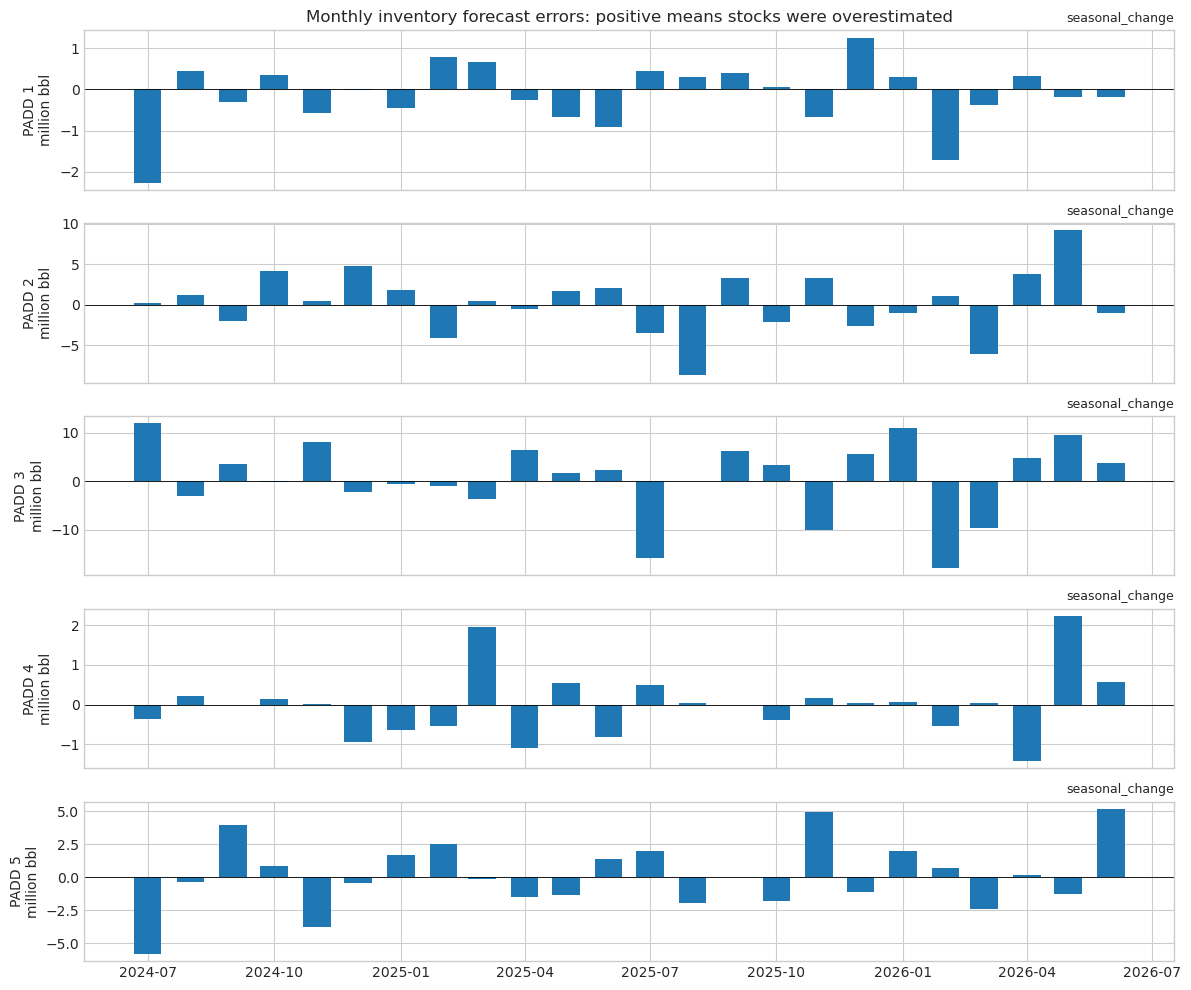

In [26]:
# Compare regional selected-model errors with unchanged stocks on the same
# holdout dates. Normalize MAE by average actual stocks to compare PADD sizes;
# positive percentage improvement means lower error than the benchmark.

# Compare like-for-like regional errors on the same final 24 months.
regional_test = tables['padd_predictions'].query("split == 'holdout'")
selected_names = tables['selected_models'][['padd','selected_model']]
regional_selected = regional_test.merge(selected_names, on='padd')
regional_selected = regional_selected[regional_selected.model.eq(regional_selected.selected_model)]
rows = []
for padd, g in regional_selected.groupby('padd'):
    baseline = regional_test[regional_test.padd.eq(padd) & regional_test.model.eq('persistence')]
    # Align selected and persistence forecasts on the same month within this PADD.
    # Validate unique matches so benchmark improvement is a like-for-like comparison.
    paired = g.merge(baseline[['month','predicted_kb']], on='month', suffixes=('', '_unchanged'), validate='one_to_one')
    # Positive signed error means overestimated stocks; absolute error measures
    # miss size, while mean signed error below measures systematic bias.
    error = paired.predicted_kb - paired.actual_kb
    baseline_mae = (paired.predicted_kb_unchanged - paired.actual_kb).abs().mean()
    # Keep the row label of the largest absolute miss to retrieve its calendar month.
    worst = error.abs().idxmax()
    rows.append({'PADD': padd, 'Average error (kb)': error.abs().mean(),
        'Error / average stocks (%)': 100 * error.abs().mean() / paired.actual_kb.mean(),
        'Improvement over unchanged stocks (%)': 100 * (1 - error.abs().mean() / baseline_mae),
        'Average bias (kb)': error.mean(), 'Worst month': paired.loc[worst, 'month'],
        'Largest miss (kb)': error.abs().max()})
regional_review = pd.DataFrame(rows)
display(regional_review)
# Persist regional diagnostics; charts convert kb to million barrels by /1000.
regional_review.to_csv(OUTPUT/'regional_error_review.csv', index=False)
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, (padd, g) in zip(axes, regional_selected.groupby('padd')):
    ax.bar(g.month, (g.predicted_kb-g.actual_kb)/1000, width=20)
    ax.axhline(0, color='black', linewidth=.6)
    ax.set_ylabel(f'PADD {padd}\nmillion bbl')
    ax.set_title(g.selected_model.iloc[0], fontsize=9, loc='right')
axes[0].set_title('Monthly inventory forecast errors: positive means stocks were overestimated')
plt.tight_layout(); plt.show()

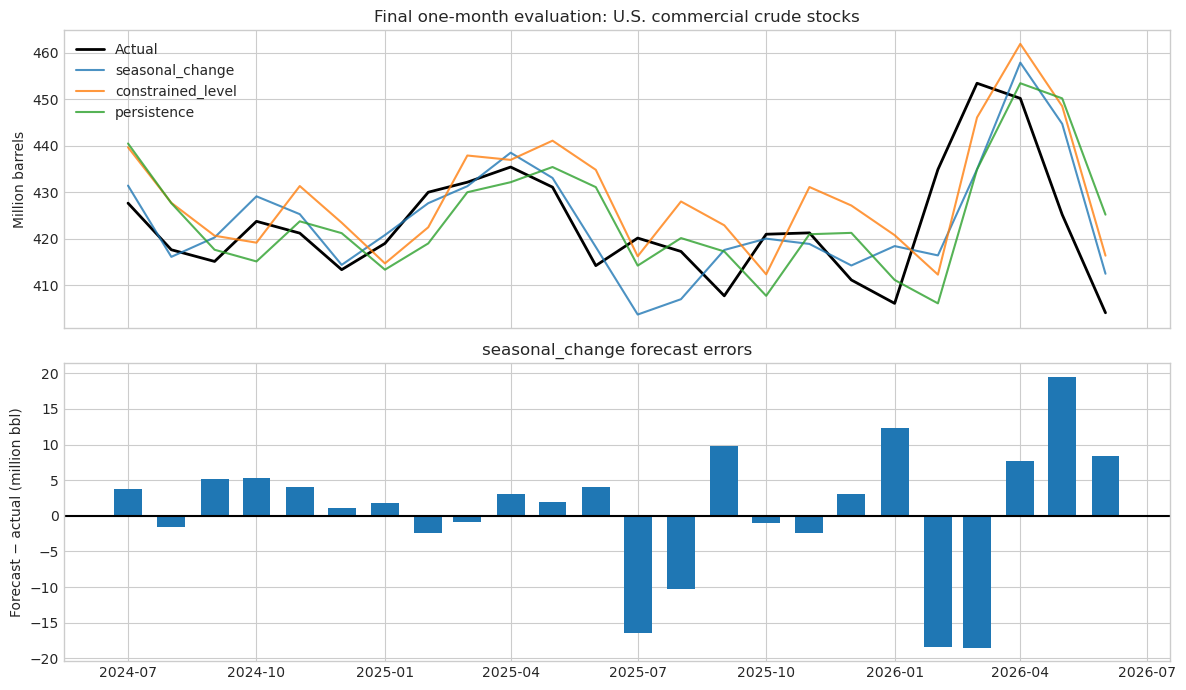

In [27]:
# Use one model's actual column to plot national stocks once, then overlay
# candidate forecasts and signed selected-model errors. Divide kb by 1000
# for million-barrel axes; a positive error bar means excess predicted stocks.

hold=tables['us_predictions'].query("split=='holdout'")
one_month_model = metadata['one_month_model']
actual=hold[hold.model.eq(one_month_model)]
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
axes[0].plot(actual.month,actual.actual_kb/1000,color='black',linewidth=2,label='Actual')
for name in [one_month_model,'constrained_level','persistence']:
    g=hold[hold.model.eq(name)]
    axes[0].plot(g.month,g.predicted_kb/1000,label=name,alpha=.8)
axes[0].set(title='Final one-month evaluation: U.S. commercial crude stocks',ylabel='Million barrels');axes[0].legend()
axes[1].bar(actual.month,(actual.predicted_kb-actual.actual_kb)/1000,width=20)
axes[1].axhline(0,color='black');axes[1].set(ylabel='Forecast − actual (million bbl)',title=f'{one_month_model} forecast errors')
plt.tight_layout();plt.show()

,model,mae_kb,rmse_kb,r2,n
0,constrained_level,"28,781.81","38,347.05",-0.51,72
1,xgboost_change,"28,919.88","39,424.45",-0.60,72
2,damped_ridge_change,"29,341.30","37,692.35",-0.46,72
3,random_forest_change,"29,822.63","42,305.12",-0.84,72
4,ensemble_change,"29,866.45","39,904.73",-0.64,72
5,persistence,"29,870.10","36,728.66",-0.39,72
6,seasonal_residual_change,"30,349.95","40,776.48",-0.71,72
7,seasonal_change,"30,562.80","42,345.68",-0.84,72
8,neural_network_change,"30,788.51","41,904.48",-0.81,72
9,seasonal_ridge_change,"31,776.08","41,092.61",-0.74,72


,first_target,last_target
origin_month,,
2016-06-01,2016-07-01,2017-06-01
2017-06-01,2017-07-01,2018-06-01
2018-06-01,2018-07-01,2019-06-01
2021-06-01,2021-07-01,2022-06-01
2022-06-01,2022-07-01,2023-06-01
2023-06-01,2023-07-01,2024-06-01


,mean,median,max
model,,,
constrained_level,"9,055.39","7,937.23","29,209.14"
persistence,"10,952.65","9,668.00","39,174.00"
seasonal_change,"11,313.40","10,463.60","41,696.80"


model,constrained_level,persistence,seasonal_change
horizon,,,
1,"7,795.34","7,190.69","3,954.18"
2,"8,871.62","10,117.62","6,913.70"
3,"9,625.49","10,605.85","8,737.63"
4,"9,610.92","12,202.69","9,926.27"
5,"8,631.78","12,647.62","11,138.46"
6,"7,784.86","11,781.00","12,218.46"
7,"8,533.26","12,079.77","11,995.90"
8,"9,323.87","12,631.77","12,896.13"
9,"10,022.13","11,347.77","14,962.32"


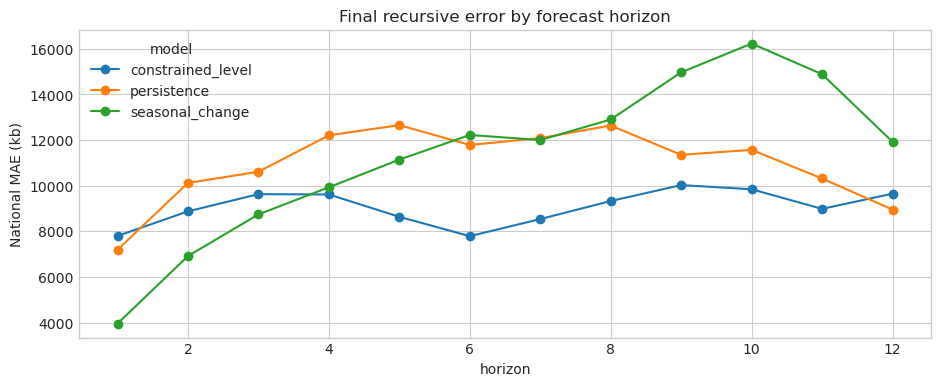

In [28]:
# Check recursive development targets precede the holdout, then summarize final
# recursive errors across paths and by lead month. Later horizons repeatedly
# use predicted history, unlike the actual-prior-input one-step evaluation.

display(tables['year_ahead_model_cv_metrics'])
cv_paths=tables['us_recursive_cv_predictions']
display(cv_paths[cv_paths.model.eq('persistence')].groupby('origin_month').agg(first_target=('month','min'),last_target=('month','max')))
assert cv_paths.month.max()<pd.Timestamp(metadata['holdout_start'])
recursive=tables['us_recursive_holdout_predictions'].copy()
recursive['abs_error_kb']=(recursive.predicted_kb-recursive.actual_kb).abs()
recursive_summary=recursive.groupby('model').abs_error_kb.agg(['mean','median','max'])
display(recursive_summary)
horizon=tables['us_recursive_horizon_metrics']
display(horizon.pivot(index='horizon',columns='model',values='mae_kb'))
horizon.pivot(index='horizon',columns='model',values='mae_kb').plot(figsize=(11,4),marker='o',title='Final recursive error by forecast horizon')
plt.ylabel('National MAE (kb)');plt.show()

**Long-horizon limitation:** The development-selected `constrained_level` model has recursive final-period MAE of **9,055 kb**, versus **10,953 kb** for persistence. Historical development selection does not guarantee better forecasts after a model or market regime changes. The selected model beats persistence on these correlated evaluation paths; this is a retrospective result.

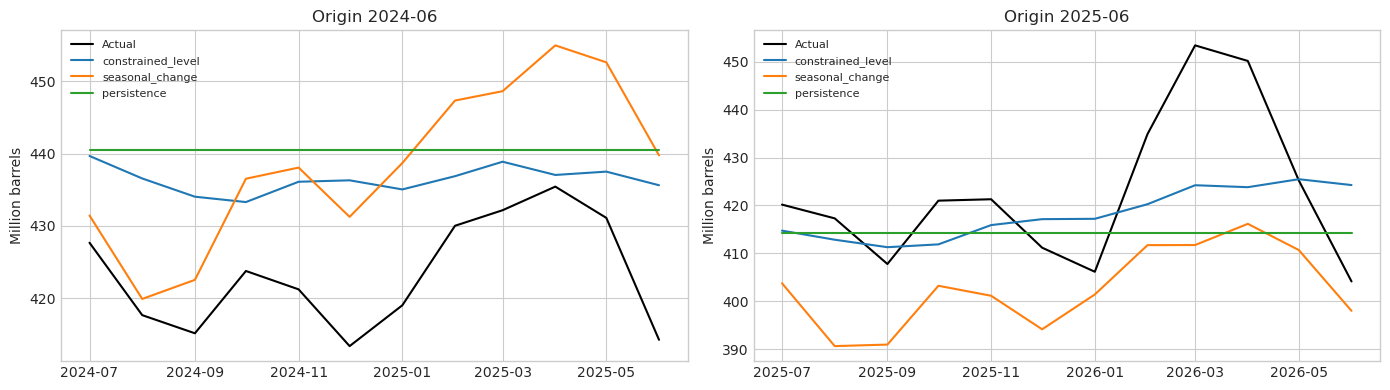

In [29]:
# Compare recursive holdout MAE with persistence and plot the earliest/latest
# forecast origins as examples. These overlapping paths are correlated evidence,
# so the observed comparison is not a guarantee of future year-ahead skill.

recursive_mae=recursive_summary.loc[metadata['year_ahead_model'],'mean']
persistence_mae=recursive_summary.loc['persistence','mean']
display(Markdown(f"**Long-horizon limitation:** The development-selected `{metadata['year_ahead_model']}` model "
    f"has recursive final-period MAE of **{recursive_mae:,.0f} kb**, versus **{persistence_mae:,.0f} kb** for persistence. "
    "Historical development selection does not guarantee better forecasts after a model or market regime changes. "
    + ("The selected model does not beat persistence in this evaluation." if recursive_mae >= persistence_mae else
     "The selected model beats persistence on these correlated evaluation paths; this is a retrospective result.")))
fig,axes=plt.subplots(1,2,figsize=(14,4))
origins=sorted(recursive.origin_month.unique())
for origin,ax in zip([origins[0],origins[-1]],axes):
    g=recursive[recursive.origin_month.eq(origin)]
    a=g[g.model.eq(metadata['year_ahead_model'])]
    ax.plot(a.month,a.actual_kb/1000,color='black',label='Actual')
    comparison_models = list(dict.fromkeys([metadata['year_ahead_model'], metadata['one_month_model'], 'persistence']))
    for name in comparison_models:
        t=g[g.model.eq(name)];ax.plot(t.month,t.predicted_kb/1000,label=name)
    ax.set(title=f'Origin {pd.Timestamp(origin):%Y-%m}',ylabel='Million barrels');ax.legend(fontsize=8)
plt.tight_layout();plt.show()

The forecast uses commercial inventories throughout. Utilization can change month by month while each region’s CDU capacity remains fixed. Persistence remains a comparison for the selected stock model.

## 10. Twelve-month supply-and-demand outlook

The outlook starts after the last observed EIA month, **June 2026**, so it spans July 2026–June 2027. Early rows may refer to already elapsed calendar months whose observations are not in this snapshot.

The published-flow projection feeds a raw accounting path. The statistical stock model can disagree with it; `model_reconciliation_kbd = predicted stock change / days in month − projected daily flow balance` exposes that disagreement. It is not an observed EIA adjustment. The raw identity path remains unclipped so impossible paths would be visible.

The one-month and 12-month models are selected separately. `latest_forecast.csv` contains the one-month model, while `*_forecast_12m.csv` contains the long-horizon model. Their selected model names are recorded in the results and metadata.

,month,production_kbd,demand_kbd,imports_kbd,exports_kbd,transfers_kbd,adjustments_kbd,cdu_capacity_kbd,utilization_ratio,balance_kbd,stock_kb,identity_stock_unclipped_kb,model_reconciliation_kbd
0,2026-07-01,"14,241.61","16,880.64","6,514.40","4,375.73",660.18,-34.30,"18,027.00",0.94,125.51,"402,441.45","408,011.76",-179.69
1,2026-08-01,"14,323.07","16,915.37","6,399.69","4,551.10",725.39,1.74,"18,027.00",0.94,-16.58,"407,121.62","407,497.70",167.56
2,2026-09-01,"14,322.92","16,436.70","6,432.55","4,469.70",775.57,-372.50,"18,027.00",0.91,252.12,"410,311.82","415,061.35",-145.78
3,2026-10-01,"14,555.87","15,956.04","6,084.56","4,598.81",800.83,-200.75,"18,027.00",0.89,685.65,"412,584.02","436,316.35",-612.35
4,2026-11-01,"14,599.41","16,652.84","6,340.41","4,624.04",713.67,-124.50,"18,027.00",0.92,252.11,"418,198.74","443,879.74",-64.96
5,2026-12-01,"14,501.79","16,725.74","6,330.31","4,687.29",703.69,-64.41,"18,027.00",0.93,58.33,"420,626.06","445,688.02",19.97
6,2027-01-01,"14,199.84","15,993.16","6,454.74","4,473.16",733.89,-323.94,"18,027.00",0.89,598.23,"422,217.11","464,233.08",-546.90
7,2027-02-01,"14,430.85","15,725.85","6,332.03","4,873.69",781.21,-70.78,"18,027.00",0.87,873.76,"425,118.40","488,698.47",-770.15
8,2027-03-01,"14,617.63","16,309.55","6,204.73","4,755.97",774.71,-63.35,"18,027.00",0.90,468.21,"430,310.96","503,212.91",-300.71
9,2027-04-01,"14,661.55","16,353.71","6,196.55","4,974.10",746.39,-54.83,"18,027.00",0.91,221.84,"431,980.62","509,868.05",-166.18


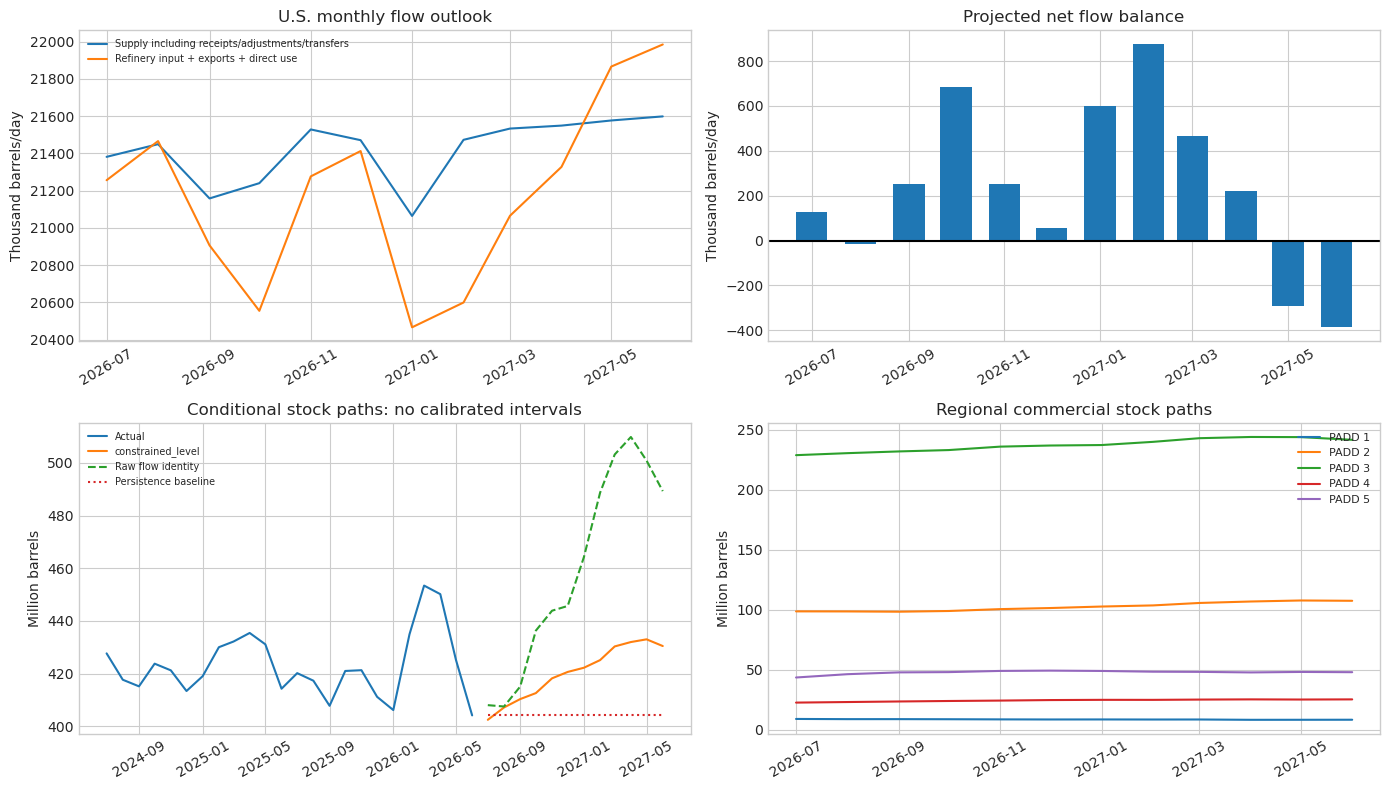

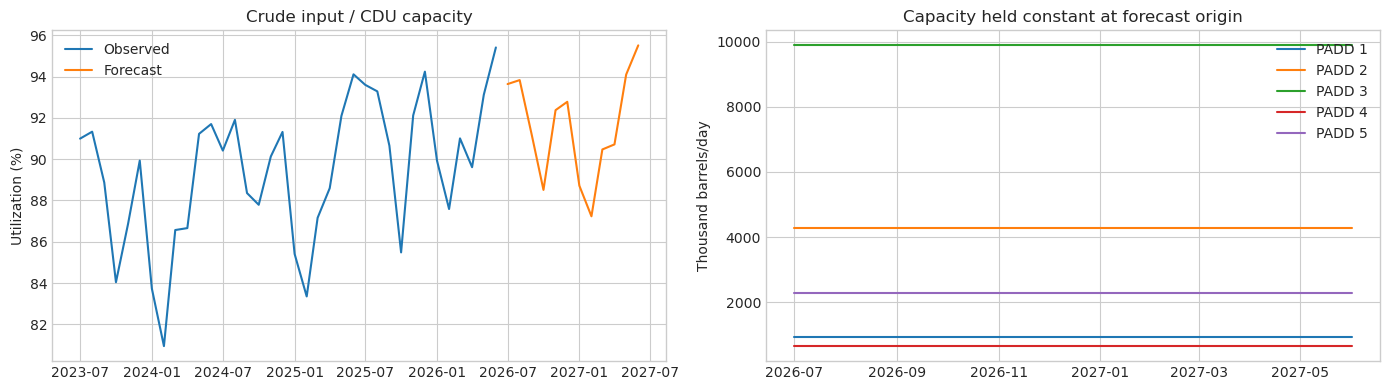

In [30]:
# Plot the conditional 12-month flow and stock outlook. The statistical stock
# path and raw accumulated flow identity need not coincide: reconciliation
# measures predicted stock change minus forecast net supply, not an observed flow.

outlook=tables['us_forecast_12m']
display(outlook[['month','production_kbd','demand_kbd','imports_kbd','exports_kbd','transfers_kbd',
    'adjustments_kbd','cdu_capacity_kbd','utilization_ratio','balance_kbd','stock_kb','identity_stock_unclipped_kb','model_reconciliation_kbd']])
fig,axes=plt.subplots(2,2,figsize=(14,8))
for c,label in [('supply_kbd','Supply including receipts/adjustments/transfers'),('total_demand_kbd','Refinery input + exports + direct use')]:
    axes[0,0].plot(outlook.month,outlook[c],label=label)
axes[0,0].set(title='U.S. monthly flow outlook',ylabel='Thousand barrels/day');axes[0,0].legend(fontsize=7)
axes[0,1].bar(outlook.month,outlook.balance_kbd,width=20)
axes[0,1].axhline(0,color='black');axes[0,1].set(title='Projected net flow balance',ylabel='Thousand barrels/day')
recent=tables['us_monthly_model'].tail(24)
axes[1,0].plot(recent.month,recent.stock_kb/1000,label='Actual')
axes[1,0].plot(outlook.month,outlook.stock_kb/1000,label=metadata['year_ahead_model'])
axes[1,0].plot(outlook.month,outlook.identity_stock_unclipped_kb/1000,label='Raw flow identity',linestyle='--')
axes[1,0].plot(outlook.month,np.repeat(recent.stock_kb.iloc[-1]/1000,12),label='Persistence baseline',linestyle=':')
axes[1,0].set(title='Conditional stock paths: no calibrated intervals',ylabel='Million barrels');axes[1,0].legend(fontsize=7)
for p,g in tables['padd_forecast_12m'].groupby('padd'):
    axes[1,1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[1,1].set(title='Regional commercial stock paths',ylabel='Million barrels');axes[1,1].legend(fontsize=8)
for ax in axes.flat:ax.tick_params(axis='x',rotation=30)
plt.tight_layout();plt.show()
fig,axes=plt.subplots(1,2,figsize=(14,4))
# Convert utilization ratios to percent for display; capacity is plotted
# separately to expose the constant-capacity forecast assumption.
axes[0].plot(tables['us_monthly_model'].tail(36).month,tables['us_monthly_model'].tail(36).utilization_ratio*100,label='Observed')
axes[0].plot(outlook.month,outlook.utilization_ratio*100,label='Forecast')
axes[0].set(title='Crude input / CDU capacity',ylabel='Utilization (%)');axes[0].legend()
for p,g in tables['padd_forecast_12m'].groupby('padd'):
    axes[1].plot(g.month,g.cdu_capacity_kbd,label=f'PADD {p}')
axes[1].set(title='Capacity held constant at forecast origin',ylabel='Thousand barrels/day');axes[1].legend()
plt.tight_layout();plt.show()
# Validate that capacity stays fixed within each PADD's forward path and
# that national demand equals aggregate utilization times aggregate capacity.
assert tables['padd_forecast_12m'].groupby('padd').cdu_capacity_kbd.nunique().eq(1).all()
np.testing.assert_allclose(outlook.demand_kbd,outlook.utilization_ratio*outlook.cdu_capacity_kbd)

## 11. Conclusions: model performance and residual diagnostics

The conclusion below summarizes the out-of-sample results using the final July 2024–June 2026 holdout. The one-month test contains 24 distinct monthly forecasts. The twelve-month test contains 13 overlapping forecast paths (156 forecast observations), so those long-horizon results are useful retrospective evidence rather than 156 independent tests.

The benchmarks are **persistence** (leave the latest observed inventory unchanged) and **same month last year** (use the inventory observed twelve months earlier). Positive improvement means the selected model has a lower MAE than the benchmark. Residuals are defined as forecast minus actual inventory, so positive values indicate overprediction.


,Evaluation,Model,MAE (million bbl),RMSE (million bbl),R²,Forecast observations
0,One month (24 distinct months),Selected: seasonal_change,6.78,9.04,0.44,24
1,One month (24 distinct months),Persistence,9.63,12.19,-0.01,24
2,One month (24 distinct months),Same month last year,10.99,13.92,-0.32,24
3,Twelve-month paths (13 overlapping origins),Selected: constrained_level,9.06,11.06,-0.08,156
4,Twelve-month paths (13 overlapping origins),Persistence,10.95,13.47,-0.60,156
5,Twelve-month paths (13 overlapping origins),Same month last year,12.14,15.39,-1.08,156


**Best one-month model — `seasonal_change`:** MAE **6.78 million bbl**, RMSE **9.04 million bbl**, and R² **0.44**. Its MAE is **29.6% lower than persistence** and **38.3% lower than the same month last year**. It ranked first among all candidates on the final one-month holdout.

**Best twelve-month-path model — `constrained_level`:** MAE **9.06 million bbl**, RMSE **11.06 million bbl**, and R² **-0.08** across the overlapping paths. Its MAE is **17.3% lower than persistence** and **25.4% lower than the same month last year**. The negative long-horizon R² means that, despite beating both practical baselines on MAE, the model does not explain holdout variation well enough to treat the twelve-month path as precise.

,Mean residual / bias (million bbl),Residual standard deviation (million bbl),Largest underprediction (million bbl),Largest overprediction (million bbl)
0,0.81,9.19,-18.49,19.50


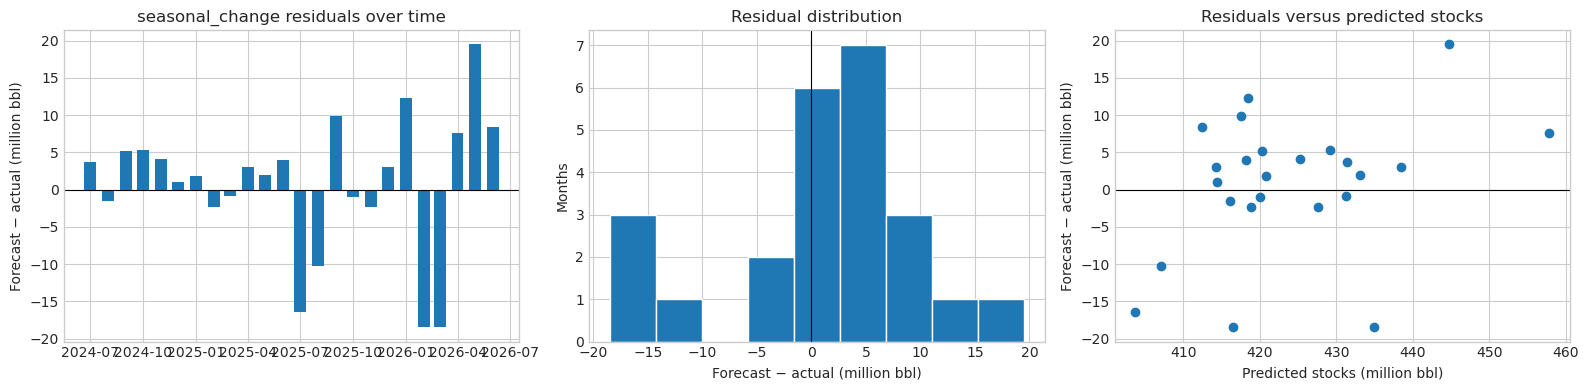

,horizon,MAE (kb),RMSE (kb),R²,Forecast observations
0,1,"7,795.34","8,878.99",-0.55,13.00
1,2,"8,871.62","11,352.80",-1.51,13.00
2,3,"9,625.49","11,332.71",-0.96,13.00
3,4,"9,610.92","11,069.69",-0.97,13.00
4,5,"8,631.78","10,357.62",-0.73,13.00
5,6,"7,784.86","9,700.49",-0.34,13.00
6,7,"8,533.26","9,684.51",-0.14,13.00
7,8,"9,323.87","11,031.90",-0.26,13.00
8,9,"10,022.13","12,851.41",0.00,13.00
9,10,"9,838.57","12,886.12",0.22,13.00


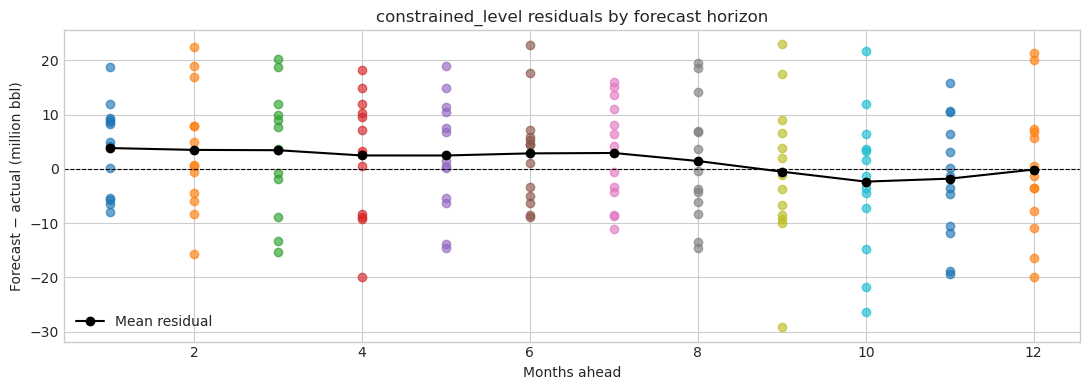

In [31]:
# Build a conclusion scorecard on held-out observations. Compare the selected
# models with unchanged stocks and the same calendar month one year earlier.
# MAE and RMSE are converted from thousand barrels to million barrels.

one_month_names = [metadata['one_month_model'], 'persistence', 'seasonal_naive']
one_month_labels = {
    metadata['one_month_model']: f"Selected: {metadata['one_month_model']}",
    'persistence': 'Persistence',
    'seasonal_naive': 'Same month last year',
}
one_month_rows = []
for name in one_month_names:
    group = hold[hold.model.eq(name)].sort_values('month')
    metrics = score(group.actual_kb, group.predicted_kb)
    one_month_rows.append({'Evaluation': 'One month (24 distinct months)',
        'Model': one_month_labels[name], **metrics})

# Each year-ahead target's year-ago stock is known at its forecast origin for
# horizons 1–12. Add that baseline on the exact same origins and target months.
year_ahead_selected = metadata['year_ahead_model']
year_ahead_base = recursive[recursive.model.eq(year_ahead_selected)].copy()
stock_by_month = tables['us_monthly_model'].set_index('month').stock_kb
year_ahead_year_ago = year_ahead_base.copy()
year_ahead_year_ago['predicted_kb'] = [
    stock_by_month.loc[month - pd.DateOffset(years=1)]
    for month in year_ahead_year_ago.month
]
year_ahead_groups = [
    (f"Selected: {year_ahead_selected}", year_ahead_base),
    ('Persistence', recursive[recursive.model.eq('persistence')]),
    ('Same month last year', year_ahead_year_ago),
]
conclusion_rows = list(one_month_rows)
for label, group in year_ahead_groups:
    metrics = score(group.actual_kb, group.predicted_kb)
    conclusion_rows.append({'Evaluation': 'Twelve-month paths (13 overlapping origins)',
        'Model': label, **metrics})

conclusion_scores = pd.DataFrame(conclusion_rows)
conclusion_scores['MAE (million bbl)'] = conclusion_scores.mae_kb / 1000
conclusion_scores['RMSE (million bbl)'] = conclusion_scores.rmse_kb / 1000
scorecard = conclusion_scores[['Evaluation', 'Model', 'MAE (million bbl)',
    'RMSE (million bbl)', 'r2', 'n']].rename(columns={'r2': 'R²', 'n': 'Forecast observations'})
display(scorecard)

one_selected = conclusion_scores.iloc[0]
one_persistence = conclusion_scores.iloc[1]
one_year_ago = conclusion_scores.iloc[2]
long_selected = conclusion_scores.iloc[3]
long_persistence = conclusion_scores.iloc[4]
long_year_ago = conclusion_scores.iloc[5]
display(Markdown(
    f"**Best one-month model — `{metadata['one_month_model']}`:** MAE **{one_selected.mae_kb/1000:.2f} million bbl**, "
    f"RMSE **{one_selected.rmse_kb/1000:.2f} million bbl**, and R² **{one_selected.r2:.2f}**. "
    f"Its MAE is **{100*(1-one_selected.mae_kb/one_persistence.mae_kb):.1f}% lower than persistence** "
    f"and **{100*(1-one_selected.mae_kb/one_year_ago.mae_kb):.1f}% lower than the same month last year**. "
    "It ranked first among all candidates on the final one-month holdout.\n\n"
    f"**Best twelve-month-path model — `{metadata['year_ahead_model']}`:** MAE **{long_selected.mae_kb/1000:.2f} million bbl**, "
    f"RMSE **{long_selected.rmse_kb/1000:.2f} million bbl**, and R² **{long_selected.r2:.2f}** across the overlapping paths. "
    f"Its MAE is **{100*(1-long_selected.mae_kb/long_persistence.mae_kb):.1f}% lower than persistence** "
    f"and **{100*(1-long_selected.mae_kb/long_year_ago.mae_kb):.1f}% lower than the same month last year**. "
    "The negative long-horizon R² means that, despite beating both practical baselines on MAE, "
    "the model does not explain holdout variation well enough to treat the twelve-month path as precise."
))

# Diagnose one-month residuals through time, by distribution, and against fitted
# inventories. A well-behaved residual series should be centered near zero with
# no persistent runs or obvious relationship to the forecast level.
one_residuals = hold[hold.model.eq(metadata['one_month_model'])].sort_values('month').copy()
one_residuals['residual_kb'] = one_residuals.predicted_kb - one_residuals.actual_kb
residual_summary = pd.DataFrame({
    'Mean residual / bias (million bbl)': [one_residuals.residual_kb.mean()/1000],
    'Residual standard deviation (million bbl)': [one_residuals.residual_kb.std(ddof=1)/1000],
    'Largest underprediction (million bbl)': [one_residuals.residual_kb.min()/1000],
    'Largest overprediction (million bbl)': [one_residuals.residual_kb.max()/1000],
})
display(residual_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(one_residuals.month, one_residuals.residual_kb/1000, width=20)
axes[0].axhline(0, color='black', linewidth=.8)
axes[0].set(title=f"{metadata['one_month_model']} residuals over time",
            ylabel='Forecast − actual (million bbl)')
axes[1].hist(one_residuals.residual_kb/1000, bins=9, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=.8)
axes[1].set(title='Residual distribution', xlabel='Forecast − actual (million bbl)',
            ylabel='Months')
axes[2].scatter(one_residuals.predicted_kb/1000, one_residuals.residual_kb/1000)
axes[2].axhline(0, color='black', linewidth=.8)
axes[2].set(title='Residuals versus predicted stocks', xlabel='Predicted stocks (million bbl)',
            ylabel='Forecast − actual (million bbl)')
plt.tight_layout(); plt.show()

# Summarize how errors accumulate across the twelve-month selected-model path.
long_residuals = year_ahead_base.copy()
long_residuals['residual_kb'] = long_residuals.predicted_kb - long_residuals.actual_kb
long_by_horizon = long_residuals.groupby('horizon').apply(
    lambda group: pd.Series(score(group.actual_kb, group.predicted_kb)),
    include_groups=False).reset_index()
display(long_by_horizon.rename(columns={'mae_kb': 'MAE (kb)', 'rmse_kb': 'RMSE (kb)',
    'r2': 'R²', 'n': 'Forecast observations'}))
fig, ax = plt.subplots(figsize=(11, 4))
for horizon_value, group in long_residuals.groupby('horizon'):
    ax.scatter(np.repeat(horizon_value, len(group)), group.residual_kb/1000, alpha=.65)
ax.plot(long_by_horizon.horizon,
        long_residuals.groupby('horizon').residual_kb.mean().values/1000,
        color='black', marker='o', label='Mean residual')
ax.axhline(0, color='black', linewidth=.8, linestyle='--')
ax.set(title=f"{year_ahead_selected} residuals by forecast horizon",
       xlabel='Months ahead', ylabel='Forecast − actual (million bbl)')
ax.legend()
plt.tight_layout(); plt.show()


### Reproducibility checks included in the notebook

Check saved inputs, the commercial stock scope, forecast timing, national aggregation, and separation of development targets from the final evaluation period. These checks run on the same inputs and outputs just used for the analysis.

In [32]:
# Check the model's stock scope and accounting identities, then perturb the
# last target observation to verify target-month isolation. Finally require
# the national forecast to equal the sum of the five regional forecasts.

assert not any('spr' in c.lower() for c in panel.columns)
np.testing.assert_allclose(panel.demand_kbd, panel.utilization_ratio * panel.cdu_capacity_kbd)
check_history=panel[panel.padd.eq(3)].iloc[:40].copy()
before=supervised(check_history)
# Perturb the final target month's stocks and flows substantially to test that
# its own inputs cannot see target-month information.
check_history.loc[check_history.index[-1],FLOWS+['stock_kb']]+=100000
changed=supervised(check_history)
# Only target labels may change after perturbing the final observation. All
# predictors, origin dates, and flow-identity forecasts must remain identical.
feature_columns=[c for c in before if c not in ['actual_kb','delta_kb']]
pd.testing.assert_frame_equal(before[feature_columns],changed[feature_columns])
np.testing.assert_allclose(tables['us_forecast_12m'].stock_kb,
    tables['padd_forecast_12m'].groupby('month').stock_kb.sum())
print('Source integrity, stock scope, target-month isolation, and aggregation checks passed.')

Source integrity, stock scope, target-month isolation, and aggregation checks passed.


In [33]:
# Inspect run configuration and saved artifacts, and validate output shape: no
# duplicate forecasts, all five PADDs each month, and a full 12-month outlook.

display(pd.Series(metadata,name='Run configuration'))
assert not tables['padd_predictions'].duplicated(['padd','month','model','split']).any()
assert tables['padd_forecast_12m'].groupby('month').padd.nunique().eq(5).all()
assert len(outlook)==12
assert len(tables['latest_forecast'])==6
assert not ((tables['us_recursive_cv_predictions'].month>=pd.Timestamp(metadata['holdout_start']))).any()
print('Notebook checks passed. Saved result files:')
for p in sorted(OUTPUT.iterdir()):print(p.name)

product                  Commercial crude oil; excludes strategic reserves
covid_exclusion          {'start': '2020-03-01', 'end': '2021-03-01', '...
stock_units                                  thousand barrels at month end
flow_units                                        thousand barrels per day
equation                 S[t] = S[t-1] + days[t] * (field production[t]...
data_start                                                      2007-01-01
data_end                                                        2026-06-01
cv                       10 expanding folds, 12 eligible test months ea...
holdout_start                                                   2024-07-01
forecast_timing          One month after latest observed EIA month; con...
selection                GridSearchCV per PADD/model on development dat...
hyperparameter_search    {'method': 'GridSearchCV', 'folds': 10, 'scori...
one_month_model                                            seasonal_change
year_ahead_model         

Notebook checks passed. Saved result files:
all_fitted_models.joblib
best_parameters.csv
candidate_addition_comparison.csv
candidate_models.json
constrained_model_coefficients.csv
fit_warnings.csv
fitted_horizon_models.joblib
fitted_models.joblib
fold_metrics.csv
grid_search_results.csv
latest_forecast.csv
model_metadata.json
national_model_cv_metrics.csv
padd_forecast_12m.csv
padd_model_coefficients.csv
padd_model_metrics.csv
padd_monthly_model.csv
padd_predictions.csv
recursive_cv_predictions.csv
recursive_holdout_metrics.csv
recursive_holdout_predictions.csv
refit_comparison.csv
regional_cv_winners.csv
regional_error_review.csv
selected_models.csv
training_sample_audit.csv
us_forecast_12m.csv
us_model_metrics.csv
us_monthly_model.csv
us_predictions.csv
us_recursive_cv_predictions.csv
us_recursive_holdout_predictions.csv
us_recursive_horizon_metrics.csv
year_ahead_model_cv_metrics.csv
year_ahead_refit_comparison.csv
